In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using linear bias $b=\sqrt{\xi_{qq}/\xi_{mm}}$
## Define a function

In [3]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [4]:
def narrow(tab_datahi_mask_zbin0, key_zbin0 = '', z1 = 0.9, z2 = 2.2):
    
    tab_datahi_mask_zbin0_narrow = tab_datahi_mask_zbin0[(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0] > z1) & (tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0] < z2)]
    # a = 1/(1+np.mean(tab_datahi_mask_zbin0_narrow['redshift_quaia'+key_zbin0]))
    a = a_median(tab_datahi_mask_zbin0_narrow, key_zbin0)
    
    return tab_datahi_mask_zbin0_narrow, a

In [5]:
def bias(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

## Parameters

In [6]:
G_hi = 20.5
G_lo = 20.0

In [7]:
nthreads = 18

In [8]:
# cosmology 1
h=0.6844
Omega_m = 0.302

# cosmology 2
Omega_m_quaia = 0.343
h_quaia = 0.674

In [9]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [10]:
H0 = h*100 * u.km/u.s/u.Mpc
rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

H0_quaia = h_quaia*100 * u.km/u.s/u.Mpc
rbins_Mpc_quaia = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0_quaia))

In [11]:
color1 = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, 2))[::-1]
color2 = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, 2))[::-1]

In [12]:
color3 = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, 2))[::-1]

In [13]:
# Create the bins array
rpmin = 0.15 # 0.5 # 0.1 # start higher
rpmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rpbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [14]:
pimax = 80 # 40 # 5000.0 # 40.0

In [15]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

In [16]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
z_array = range(len(z_bins)-1)
mask = 0.5

In [17]:
tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, 0, True, 'z', n_bins = 1,
                                                                                        tab_gcat_type = 'data', fac_rand = 25)

Leaving tab_gcat_catalog unbinned
G20.5: 0.15              1102599 vs 1295502


In [18]:
Omega_c = 0.2513
Omega_b = 0.048
Omega_m_planck = Omega_c+Omega_b
cosmo = ccl.Cosmology(Omega_c=Omega_m*Omega_c/Omega_m_planck, Omega_b=Omega_m*Omega_b/Omega_m_planck,
                          h=h, n_s=0.95, sigma8=0.8)
cosmo_quaia = ccl.Cosmology(Omega_c=Omega_m_quaia*Omega_c/Omega_m_planck, Omega_b=Omega_m_quaia*Omega_b/Omega_m_planck,
                          h=h_quaia, n_s=0.95, sigma8=0.766)
a = a_median(tab_datahi_mask_zbin0)

In [19]:
cmap_qq = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(z_array)))
cmap_mm = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))
cmap_b = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_qq, cmap_mm]

In [20]:
orange = plt.get_cmap('Oranges')((0.333+0.999)/2)
green = plt.get_cmap('Greens')((0.333+0.999)/2)
colors = [orange, green]

# Measure bias in a narrow $z$ range: 0.9 < $z$ < 2.2 to match Fig. 8 of [this paper](https://arxiv.org/abs/1705.04718)
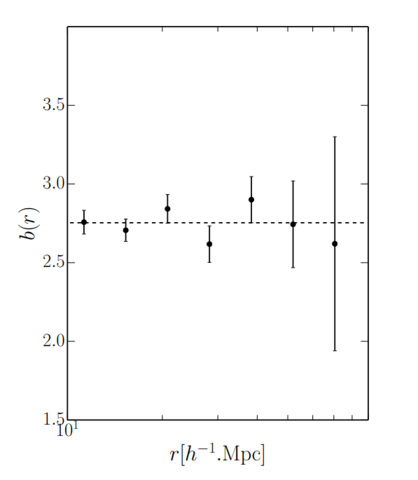
## For $\xi(s)$
### Define a function

In [21]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

cf_narrow, cf_matter_narrow = [], []
for i in range(len(Omega_m_array)):
    
    tab_datahi_mask_zbin0_narrow, a = narrow(tab_datahi_mask_zbin0)
    cf_narrow.append(quaia.xi_s(tab_datahi_mask_zbin0_narrow, narrow(tab_randhi_mask_zbin0, key_zbin0 = '_'+key_zbin0)[0], key_zbin0, nthreads = nthreads, 
               rbins = rbins, Om0 = Omega_m_array[i], h = h_array[i]))

    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

    cf_matter_narrow.append(ccl.correlations.correlation_3d(cosmos[i], r=rbins_Mpc, a=a))

[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


/tmp/ipykernel_157745/958354518.py:14: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_narrow[i]/cf_matter_narrow[i]), linewidth = 2.5, marker = 'o', label = labels[i], color = color3[i], linestyle = linestyles[i])


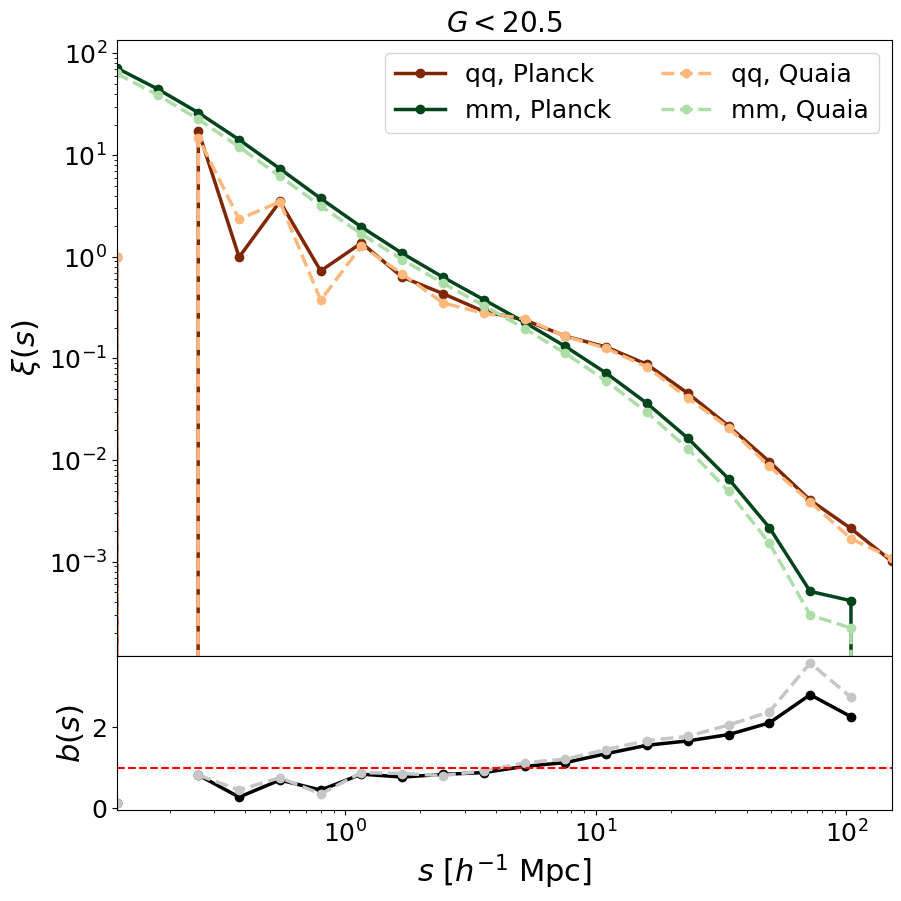

In [22]:
fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(2, 1, hspace = 0, height_ratios = [4,1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# label_array = ['Planck', 'Quaia']
labels = ['Planck', 'Quaia']
for i in range(len(Omega_m_array)):
    
    ax1.plot(quaia.recenter(rbins), cf_narrow[i], linewidth = 2.5, marker = 'o', label = r'qq, '+ labels[i], color = color1[i], linestyle = linestyles[i])
    ax1.plot(quaia.recenter(rbins), cf_matter_narrow[i], linewidth = 2.5, marker = 'o', label = r'mm, '+labels[i], color = color2[i], linestyle = linestyles[i])
    
    ax2.plot(quaia.recenter(rbins), np.sqrt(cf_narrow[i]/cf_matter_narrow[i]), linewidth = 2.5, marker = 'o', label = labels[i], color = color3[i], linestyle = linestyles[i])

ax1.set_title('$G<{}$'.format(G_hi))
if scale == 'log':
    ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_ylabel(r'$\xi(s)$')
ax1.legend(ncol = 2)
ax1.set_xticklabels([])

ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    ax2.set_xscale('log')
ax2.set_ylabel(r'$b(s)$')
ax2.axhline(1, linestyle = '--', color = 'red')
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])

plt.show()

## For $w_p(r_p)$

In [23]:
s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)**2, quaia.recenter(pibins)**2), axis = 0))

In [24]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']
H0_array = [H0, H0_quaia]

wp_narrow, wp_matter_narrow = [], []
rpavg_narrow = []
for i in range(len(Omega_m_array)):
    
    tab_datahi_mask_zbin0_narrow, a = narrow(tab_datahi_mask_zbin0)
    wp_narrow_i, rpavg_narrow_i = quaia.wp_rp(tab_datahi_mask_zbin0_narrow, narrow(tab_randhi_mask_zbin0, key_zbin0 = '_'+key_zbin0)[0], key_zbin0, Om0 = Omega_m_array[i], h = h_array[i],
                                                      nthreads = nthreads, rbins = rpbins, nbins = nbins, pimax = pimax)
    wp_narrow.append(wp_narrow_i)
    rpavg_narrow.append(rpavg_narrow_i)
    
    # version 3
    s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0_array[i]))
    
    xirppi_narrow = ccl.correlations.correlation_3d(cosmos[i], r=np.ravel(s_Mpc), a=a)
    wp_matter_narrow.append(2*np.trapz(np.reshape(xirppi_narrow, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0))

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


/tmp/ipykernel_157745/4139093623.py:12: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_narrow[i]/wp_matter_narrow[i]), linewidth = 2.5, marker = 'o', label = labels[i], color = color3[i], linestyle = linestyles[i]) # not sure which x axis to plot against lol


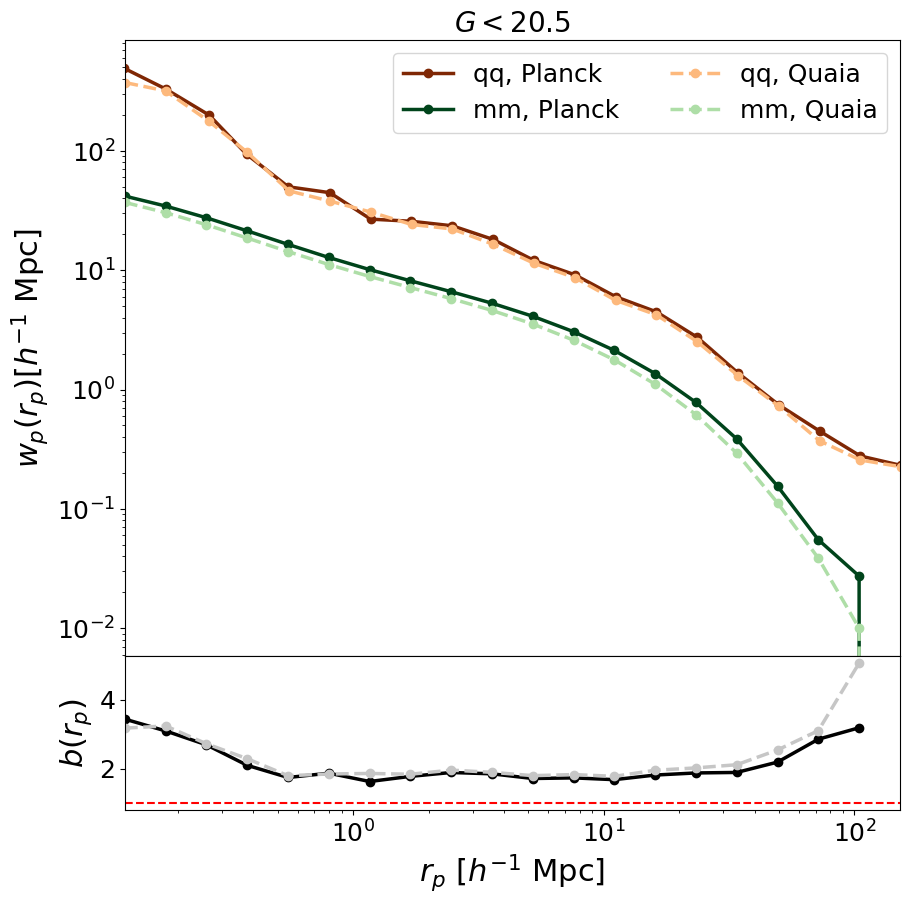

In [25]:
fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(2, 1, hspace = 0, height_ratios = [4,1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for i in range(len(Omega_m_array)):
    
    ax1.plot(rpavg_narrow[i], wp_narrow[i], linewidth = 2.5, marker = 'o', label = r'qq, '+ labels[i], color = color1[i], linestyle = linestyles[i])
    ax1.plot(quaia.recenter(rpbins), wp_matter_narrow[i], linewidth = 2.5, marker = 'o', label = r'mm, '+labels[i], color = color2[i], linestyle = linestyles[i])
    
    ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_narrow[i]/wp_matter_narrow[i]), linewidth = 2.5, marker = 'o', label = labels[i], color = color3[i], linestyle = linestyles[i]) # not sure which x axis to plot against lol

ax1.set_title('$G<{}$'.format(G_hi))
if scale == 'log':
    ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
ax1.set_ylabel(r'$w_p(r_p) [h^{-1}$ Mpc]')
ax1.legend(ncol = 2)
ax1.set_xticklabels([])

ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    ax2.set_xscale('log')
ax2.set_ylabel(r'$b(r_p)$')
ax2.axhline(1, linestyle = '--', color = 'red')
ax2.set_xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])

plt.show()

In [26]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

cf_zbin, cf_matter_zbin = {label: [] for label in labels}, {label: [] for label in labels}
for i in range(len(Omega_m_array)):
    
    for j in z_array:

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                         bins = [z_bins], tab_gcat_type = 'data',
                                                                                         method = ['minmax'], fac_rand = 25,
                                                                                         n_bins = [None], mask = mask)
        cf_zbin[labels[i]].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                   rbins = rbins, Om0 = Omega_m_array[i], h = h_array[i]))

        H0 = h_array[i]*100 * u.km/u.s/u.Mpc
        rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

        cf_matter_zbin[labels[i]].append(ccl.correlations.correlation_3d(cosmos[i], r=rbins_Mpc, a=a_median(tab_datahi_mask_zbin0)))

G20.5_zmin0.0zmax1.0: 0.22              253398 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0: 0.17              536368 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508


...

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.0: 0.46              19252 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


In [27]:
cmap_qq = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(z_array)))
cmap_mm = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))
cmap_b = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_qq, cmap_mm]

In [28]:
orange = plt.get_cmap('Oranges')((0.333+0.999)/2)
green = plt.get_cmap('Greens')((0.333+0.999)/2)
colors = [orange, green]

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/1408318656.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin[labels[i]][j]/cf_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/1408318656.py:16: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin[labels[i]][j]/cf_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/1408318656.py:16: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin[labels[i]][j]/cf_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])


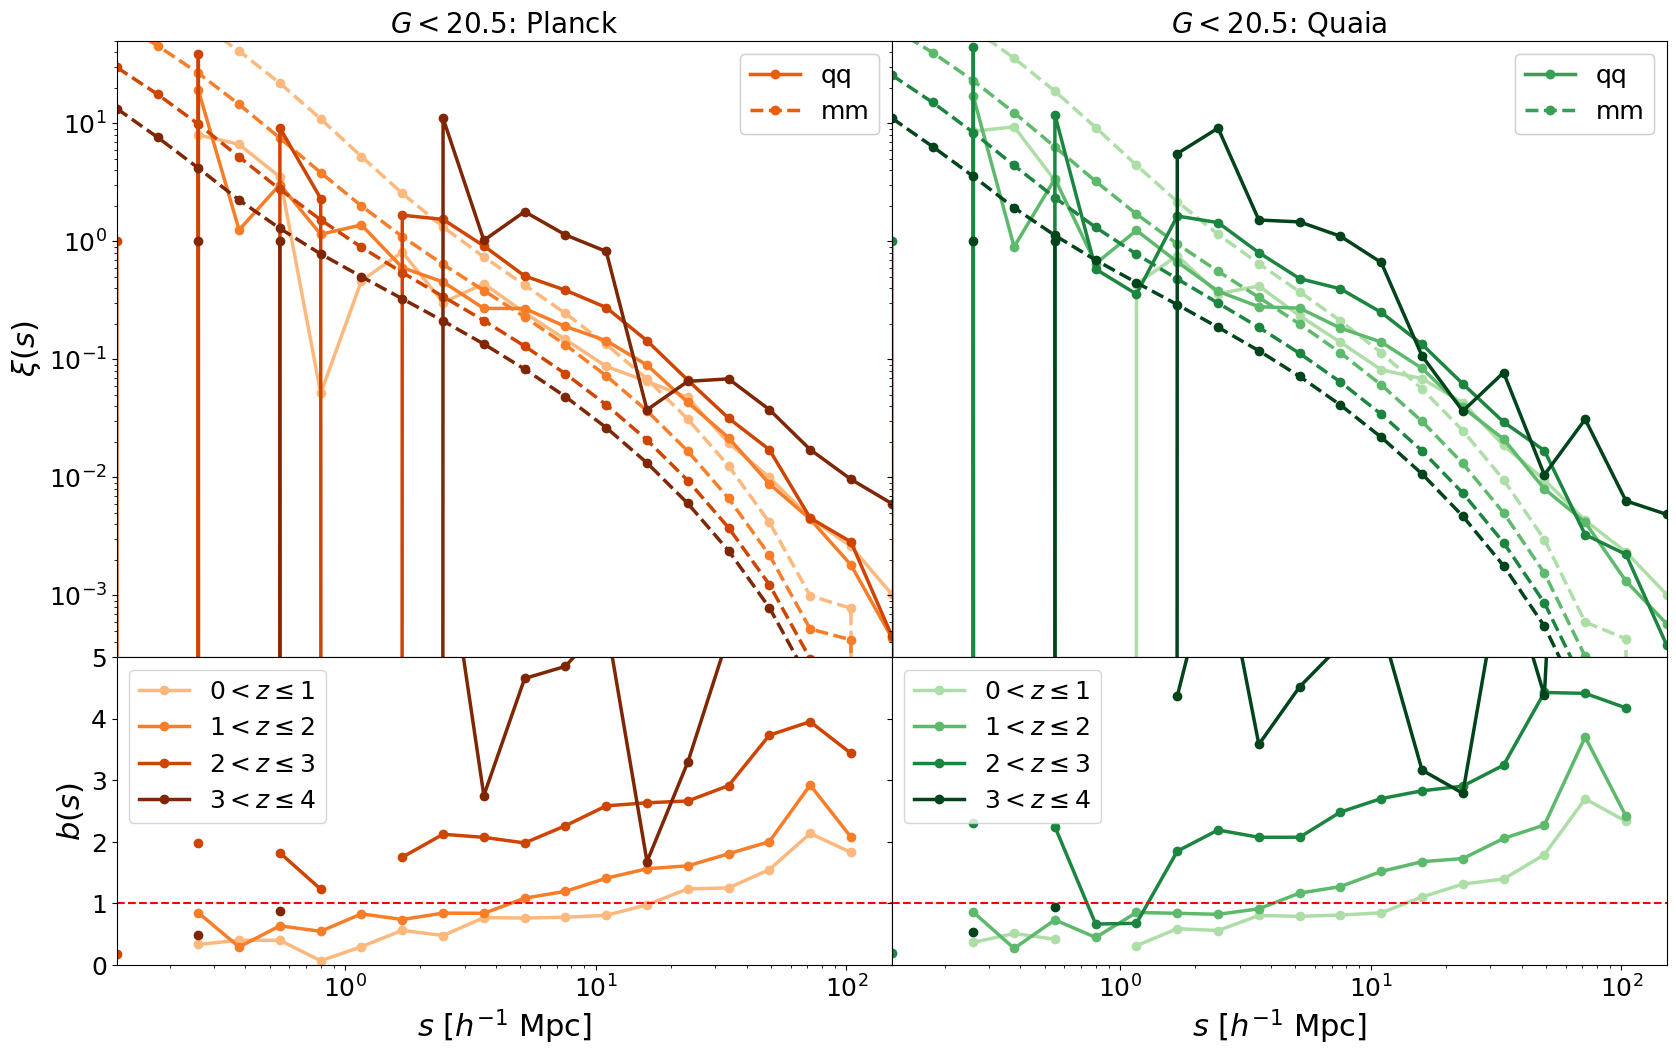

In [29]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

# labels = ['Corrfunc', 'Quaia']
labels_cf = ['qq', 'mm']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        ax1.plot(quaia.recenter(rbins), cf_zbin[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin[labels[i]][j]/cf_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')
        # ax1.legend(ncol = 2)
        
        # patch = [mpatches.Patch(color=cmap_b[k], label = '${:.0f}<z \leq{:.0f}$'.format(k, k+1)) for k in range(len(z_array))]
        # first_legend = ax2.legend(handles=patch, loc = 'upper left')
        # ax2.add_artist(first_legend)
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/1175643144.py:18: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin[labels[i]][j]/cf_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/1175643144.py:21: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_157745/1175643144.py:18: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin[labels[i]][j]/cf_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/1175643144.py:18: RuntimeWarning: invalid value encountere

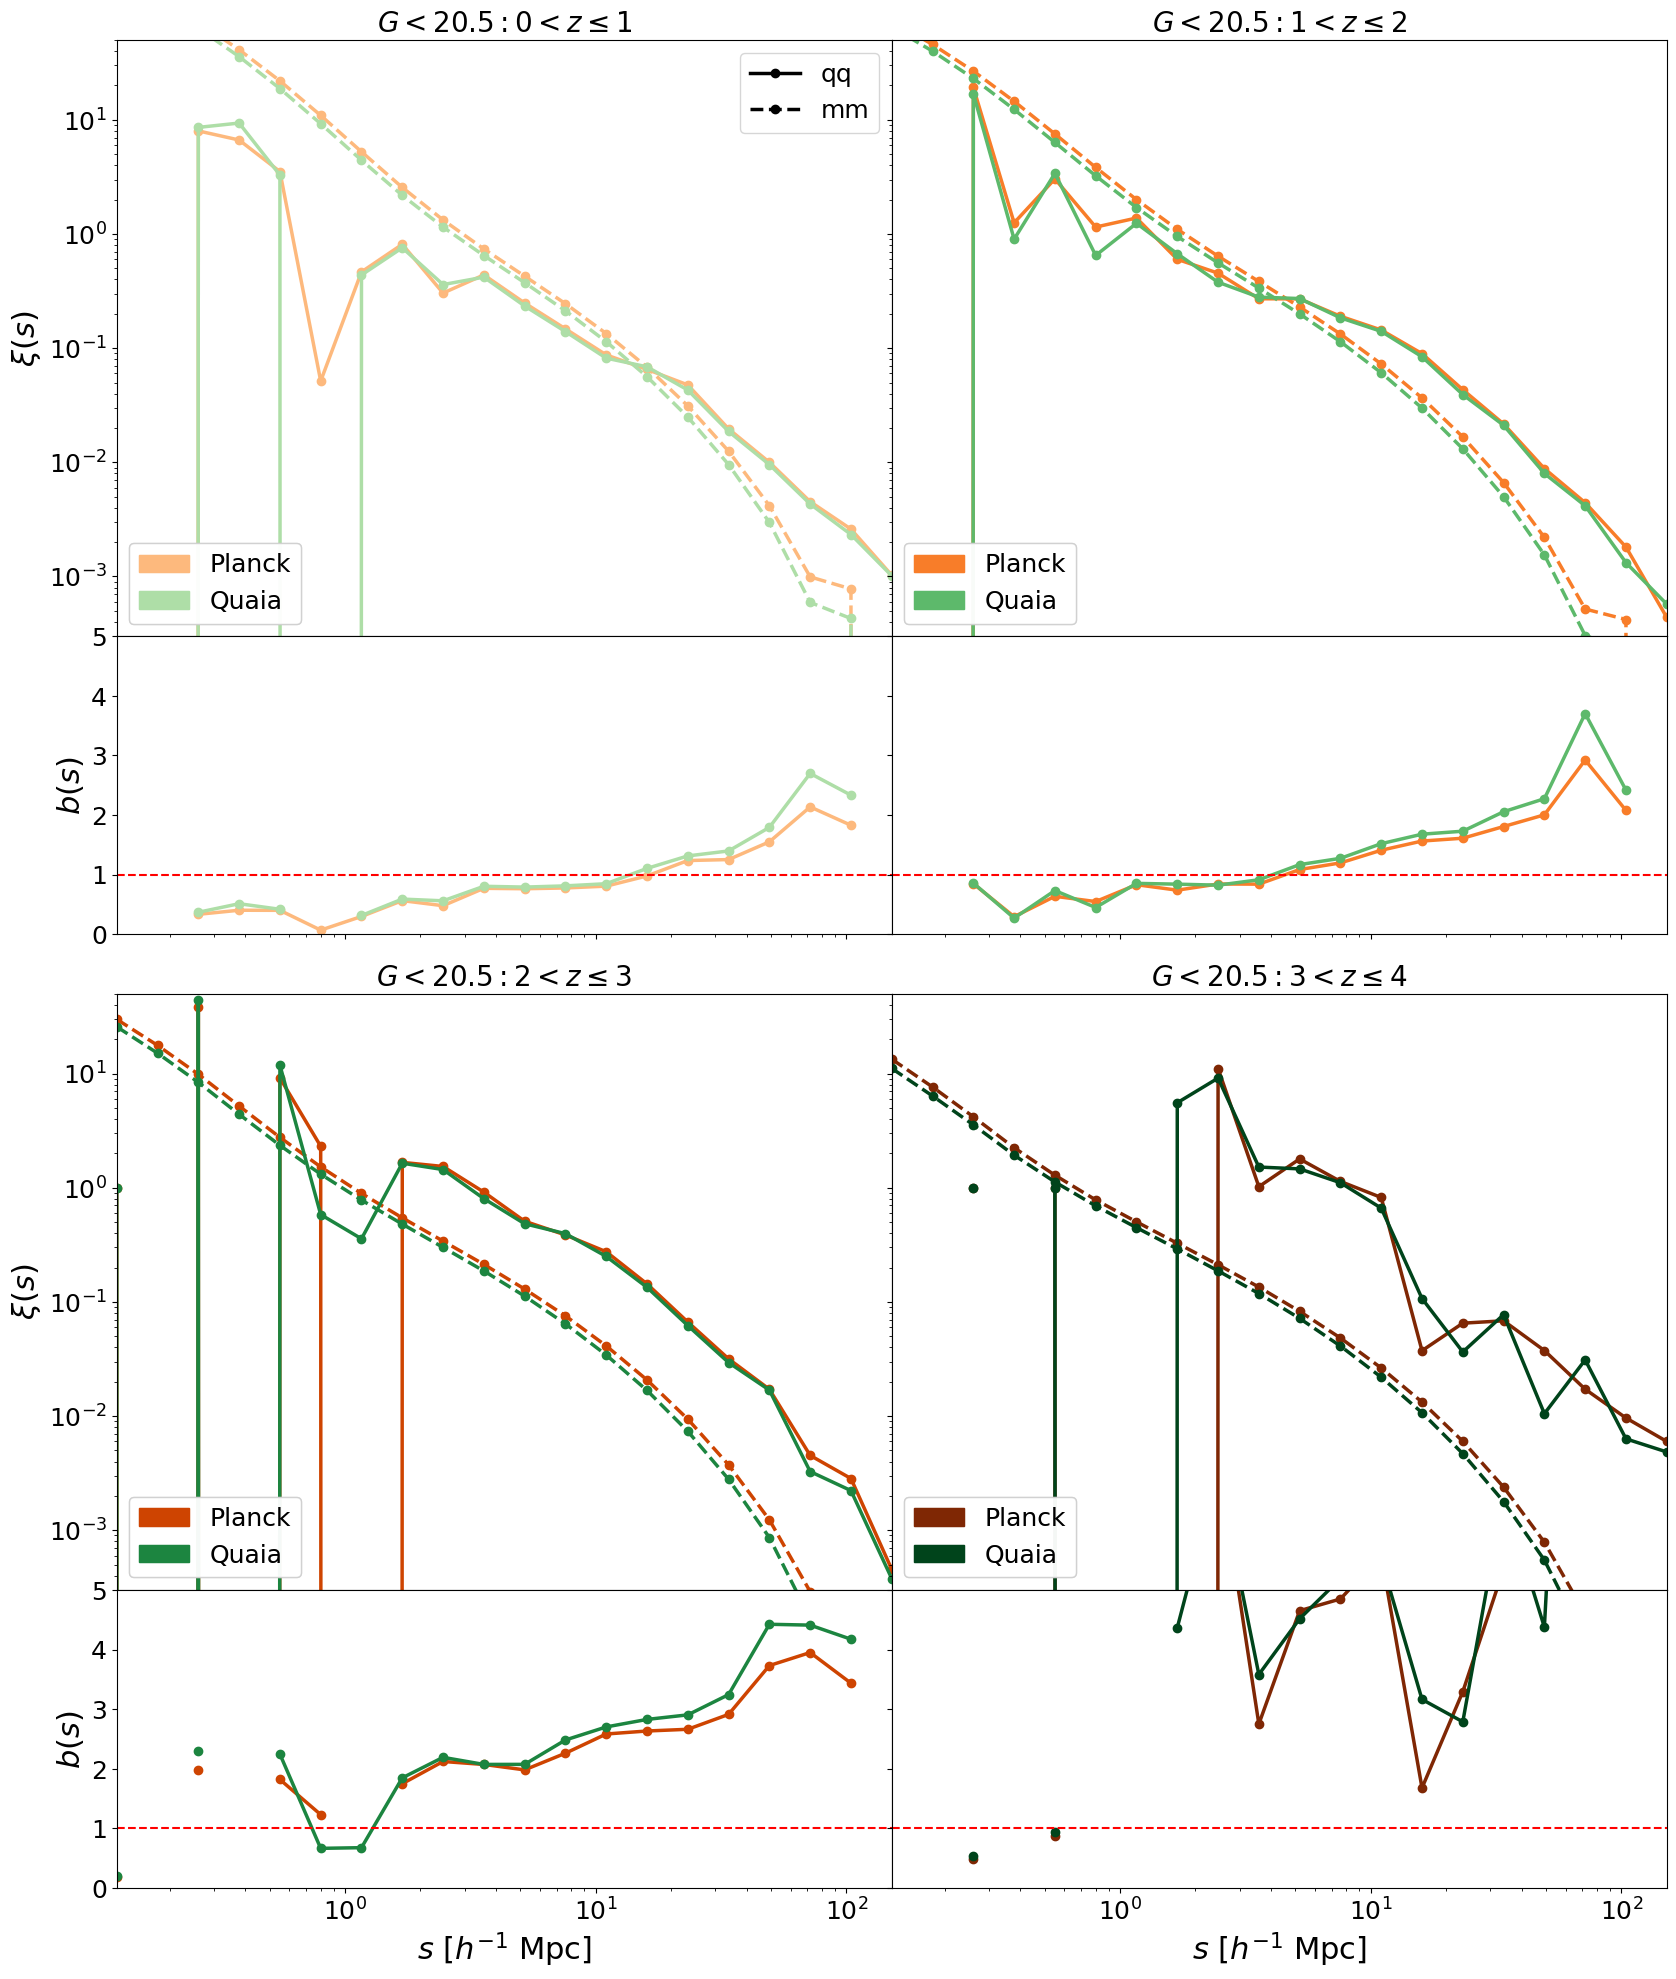

In [30]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

# labels = ['Corrfunc', 'Quaia']
labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    for i in range(len(Omega_m_array)):
    
        ax1.plot(quaia.recenter(rbins), cf_zbin[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin[labels[i]][j]/cf_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
                              # , title = 'Cosmology', title_fontsize = 18)
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

## For $w_p(r_p)$

In [31]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

wp_zbin, wp_matter_zbin = {label: [] for label in labels}, {label: [] for label in labels}
rpavg_zbin = {label: [] for label in labels}
for i in range(len(Omega_m_array)):
    
    for j in z_array:
    
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                         bins = [z_bins], tab_gcat_type = 'data',
                                                                                         method = ['minmax'], fac_rand = 25,
                                                                                         n_bins = [None], mask = mask)
        wp_zbin_i, rpavg_zbin_i = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, Om0 = Omega_m_array[i], h = h_array[i],
                                                          nthreads = nthreads, rbins = rpbins, nbins = nbins, pimax = pimax)
        wp_zbin[labels[i]].append(wp_zbin_i)
        rpavg_zbin[labels[i]].append(rpavg_zbin_i)

        # version 3
        s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0_array[i]))
        
        xirppi_zbin_i = ccl.correlations.correlation_3d(cosmos[i], r=np.ravel(s_Mpc), a=a_median(tab_datahi_mask_zbin0))
        wp_matter_zbin[labels[i]].append(2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0))

G20.5_zmin0.0zmax1.0: 0.22              253398 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0: 0.17              536368 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508


...

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.0: 0.46              19252 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:751: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/902643087.py:15: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin[labels[i]][j]/wp_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/902643087.py:15: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin[labels[i]][j]/wp_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/902643087.py:15: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin[labels[i]][j]/wp_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])


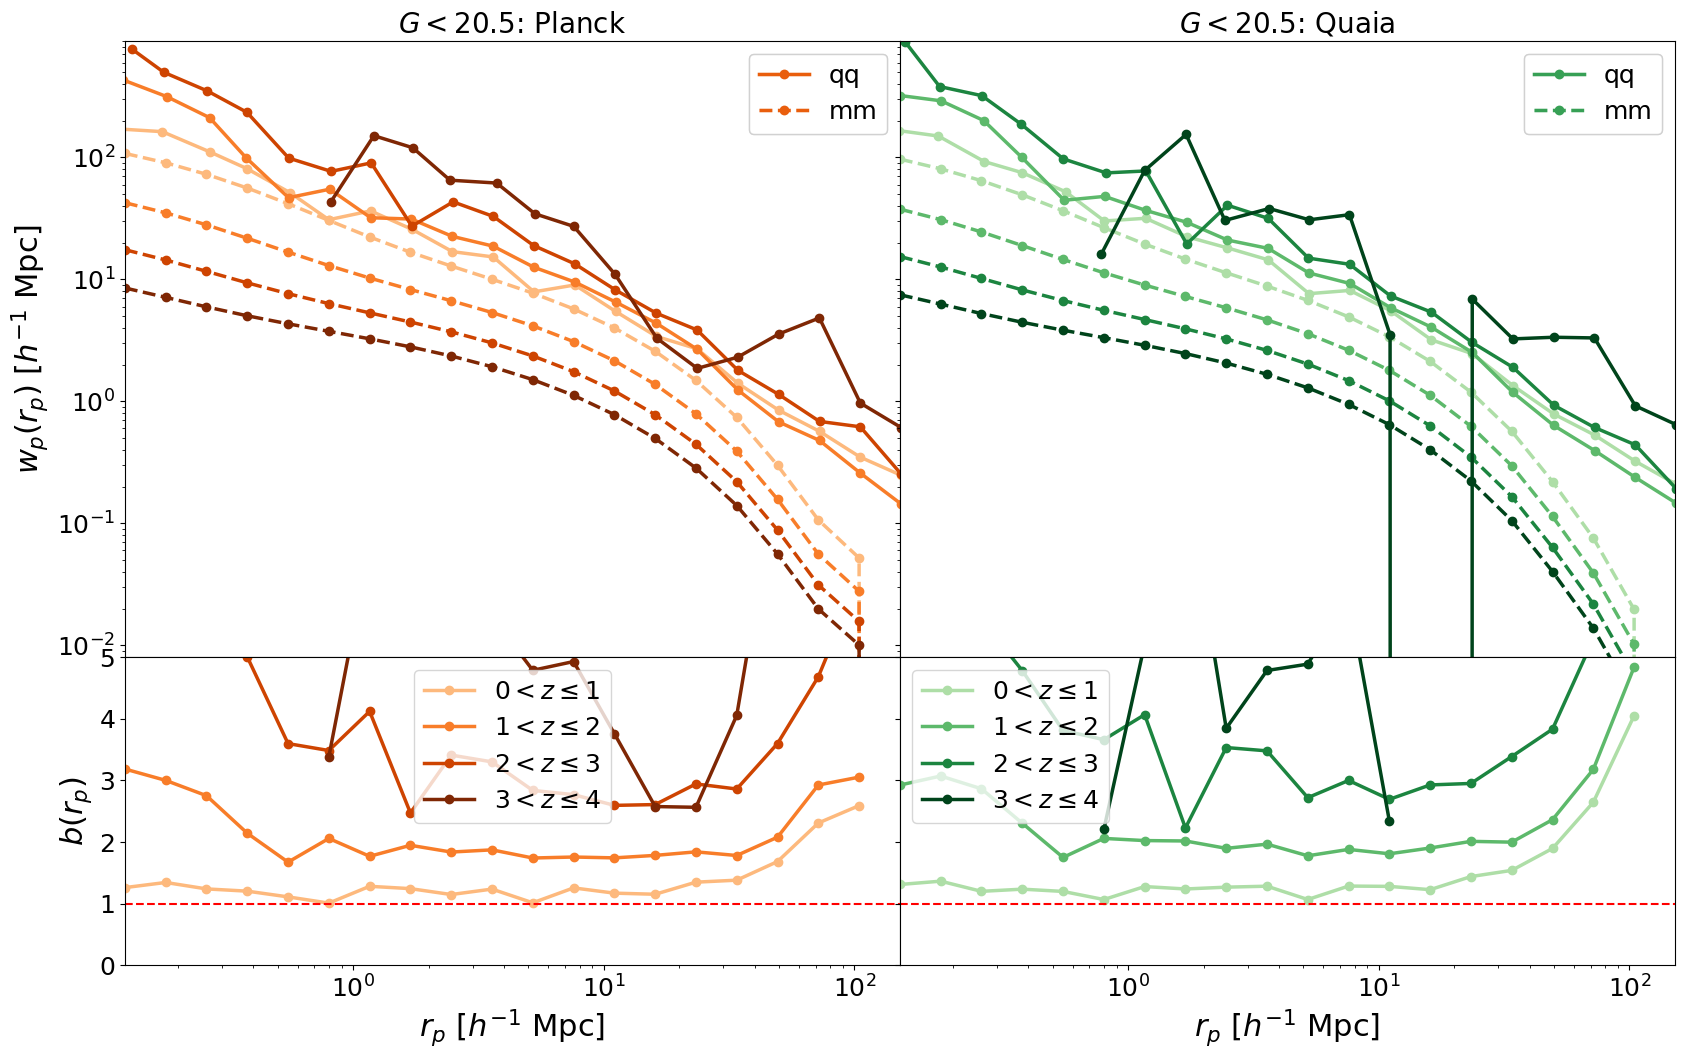

In [32]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        ax1.plot(rpavg_zbin[labels[i]][j], wp_zbin[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin[labels[i]][j]/wp_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/1546458383.py:18: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin[labels[i]][j]/wp_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/1546458383.py:21: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_157745/1546458383.py:18: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin[labels[i]][j]/wp_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/1546458383.py:18: RuntimeWarning: invalid value encounte

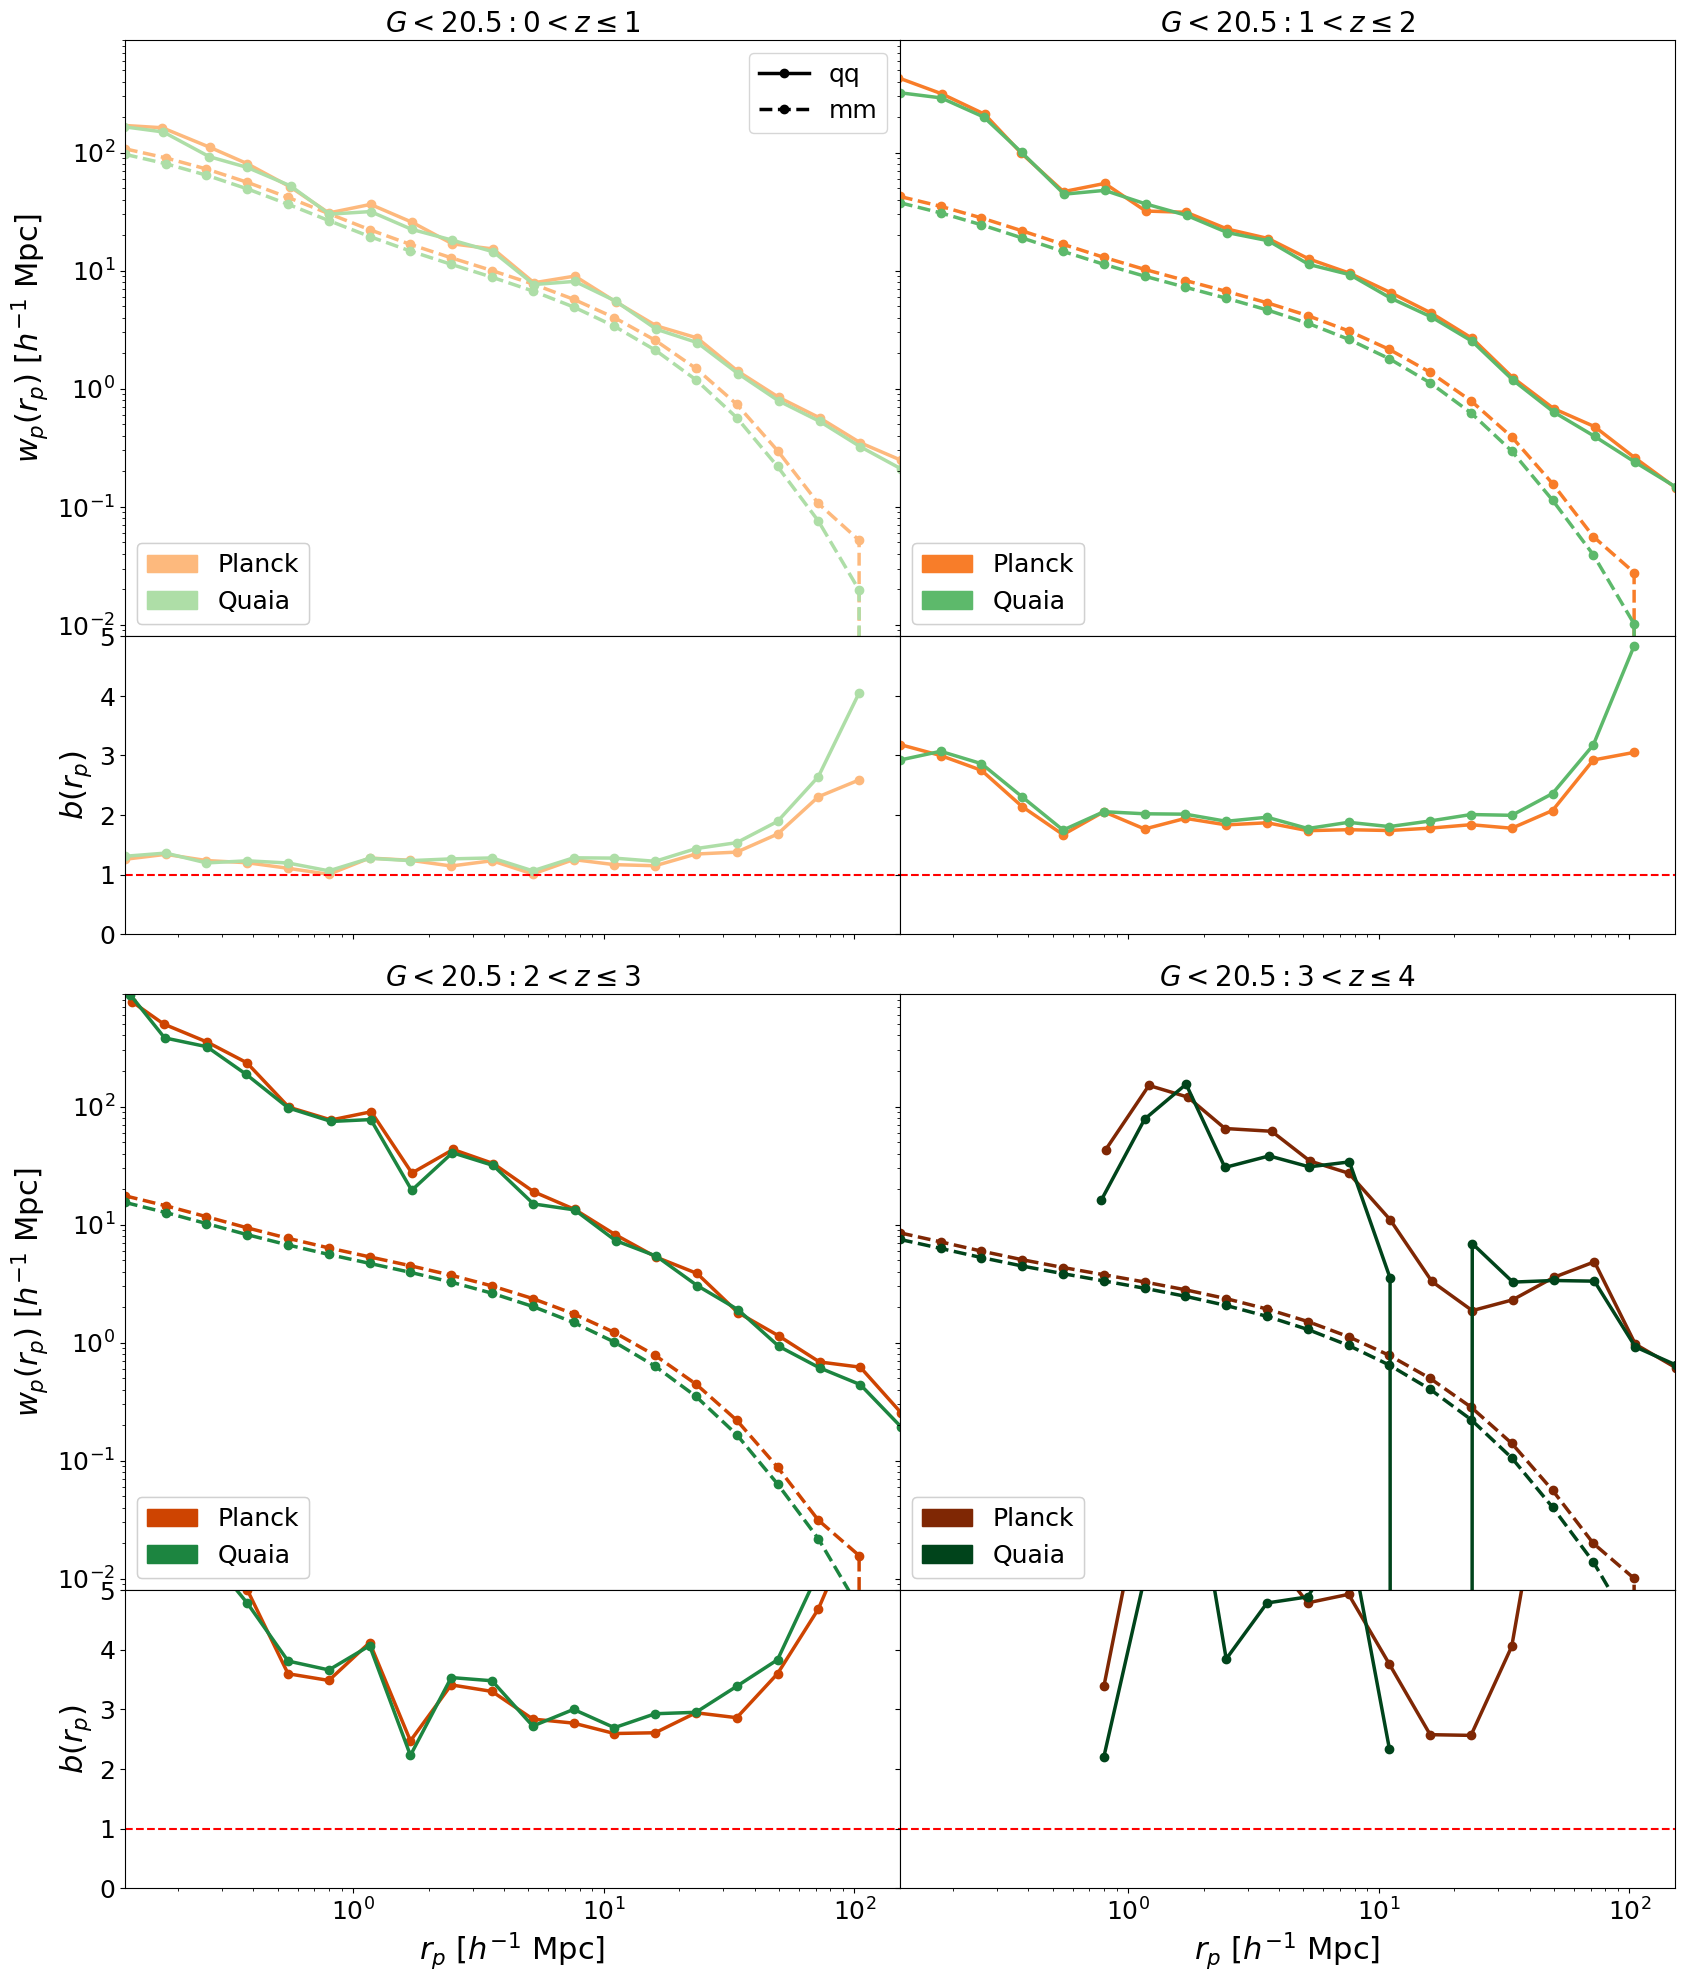

In [33]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

# labels = ['Corrfunc', 'Quaia']
labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    for i in range(len(Omega_m_array)):
    
        ax1.plot(rpavg_zbin[labels[i]][j], wp_zbin[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin[labels[i]][j]/wp_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/1442175258.py:19: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin[labels[i]][j]/cf_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/1442175258.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin[labels[i]][j]/wp_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j])
/tmp/ipykernel_157745/1442175258.py:28: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+

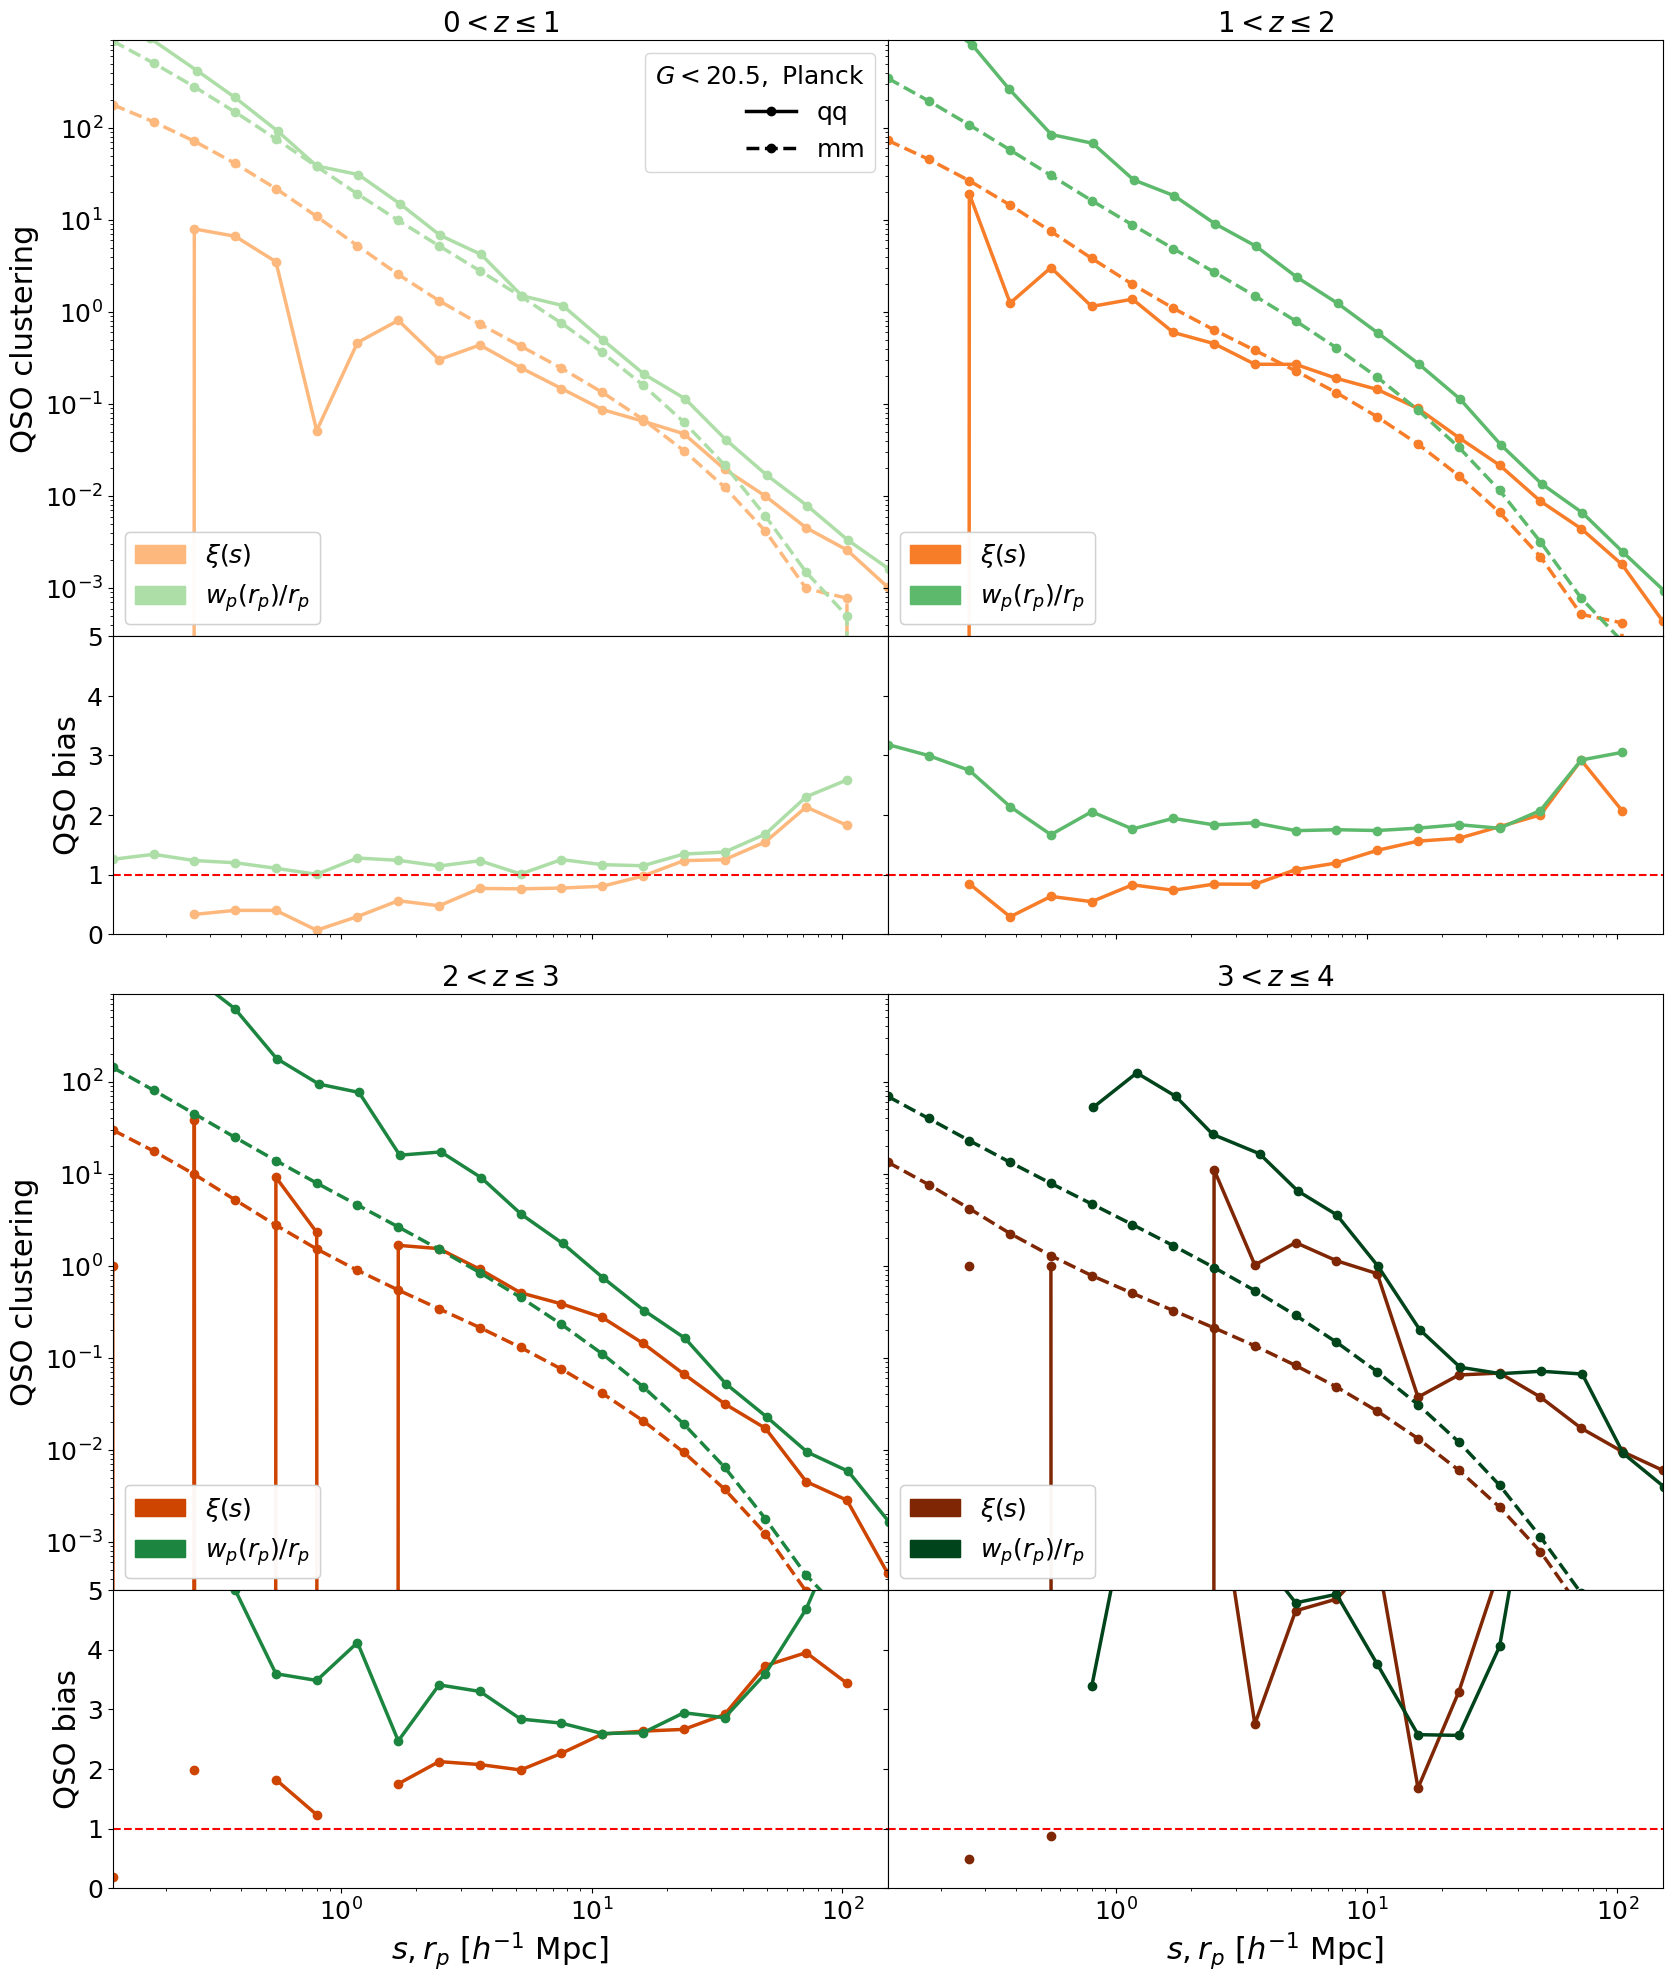

/tmp/ipykernel_157745/1442175258.py:19: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin[labels[i]][j]/cf_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/1442175258.py:25: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin[labels[i]][j]/wp_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j])
/tmp/ipykernel_157745/1442175258.py:19: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin[labels[i]][j]/cf_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/1442175258.py:25: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin[labels

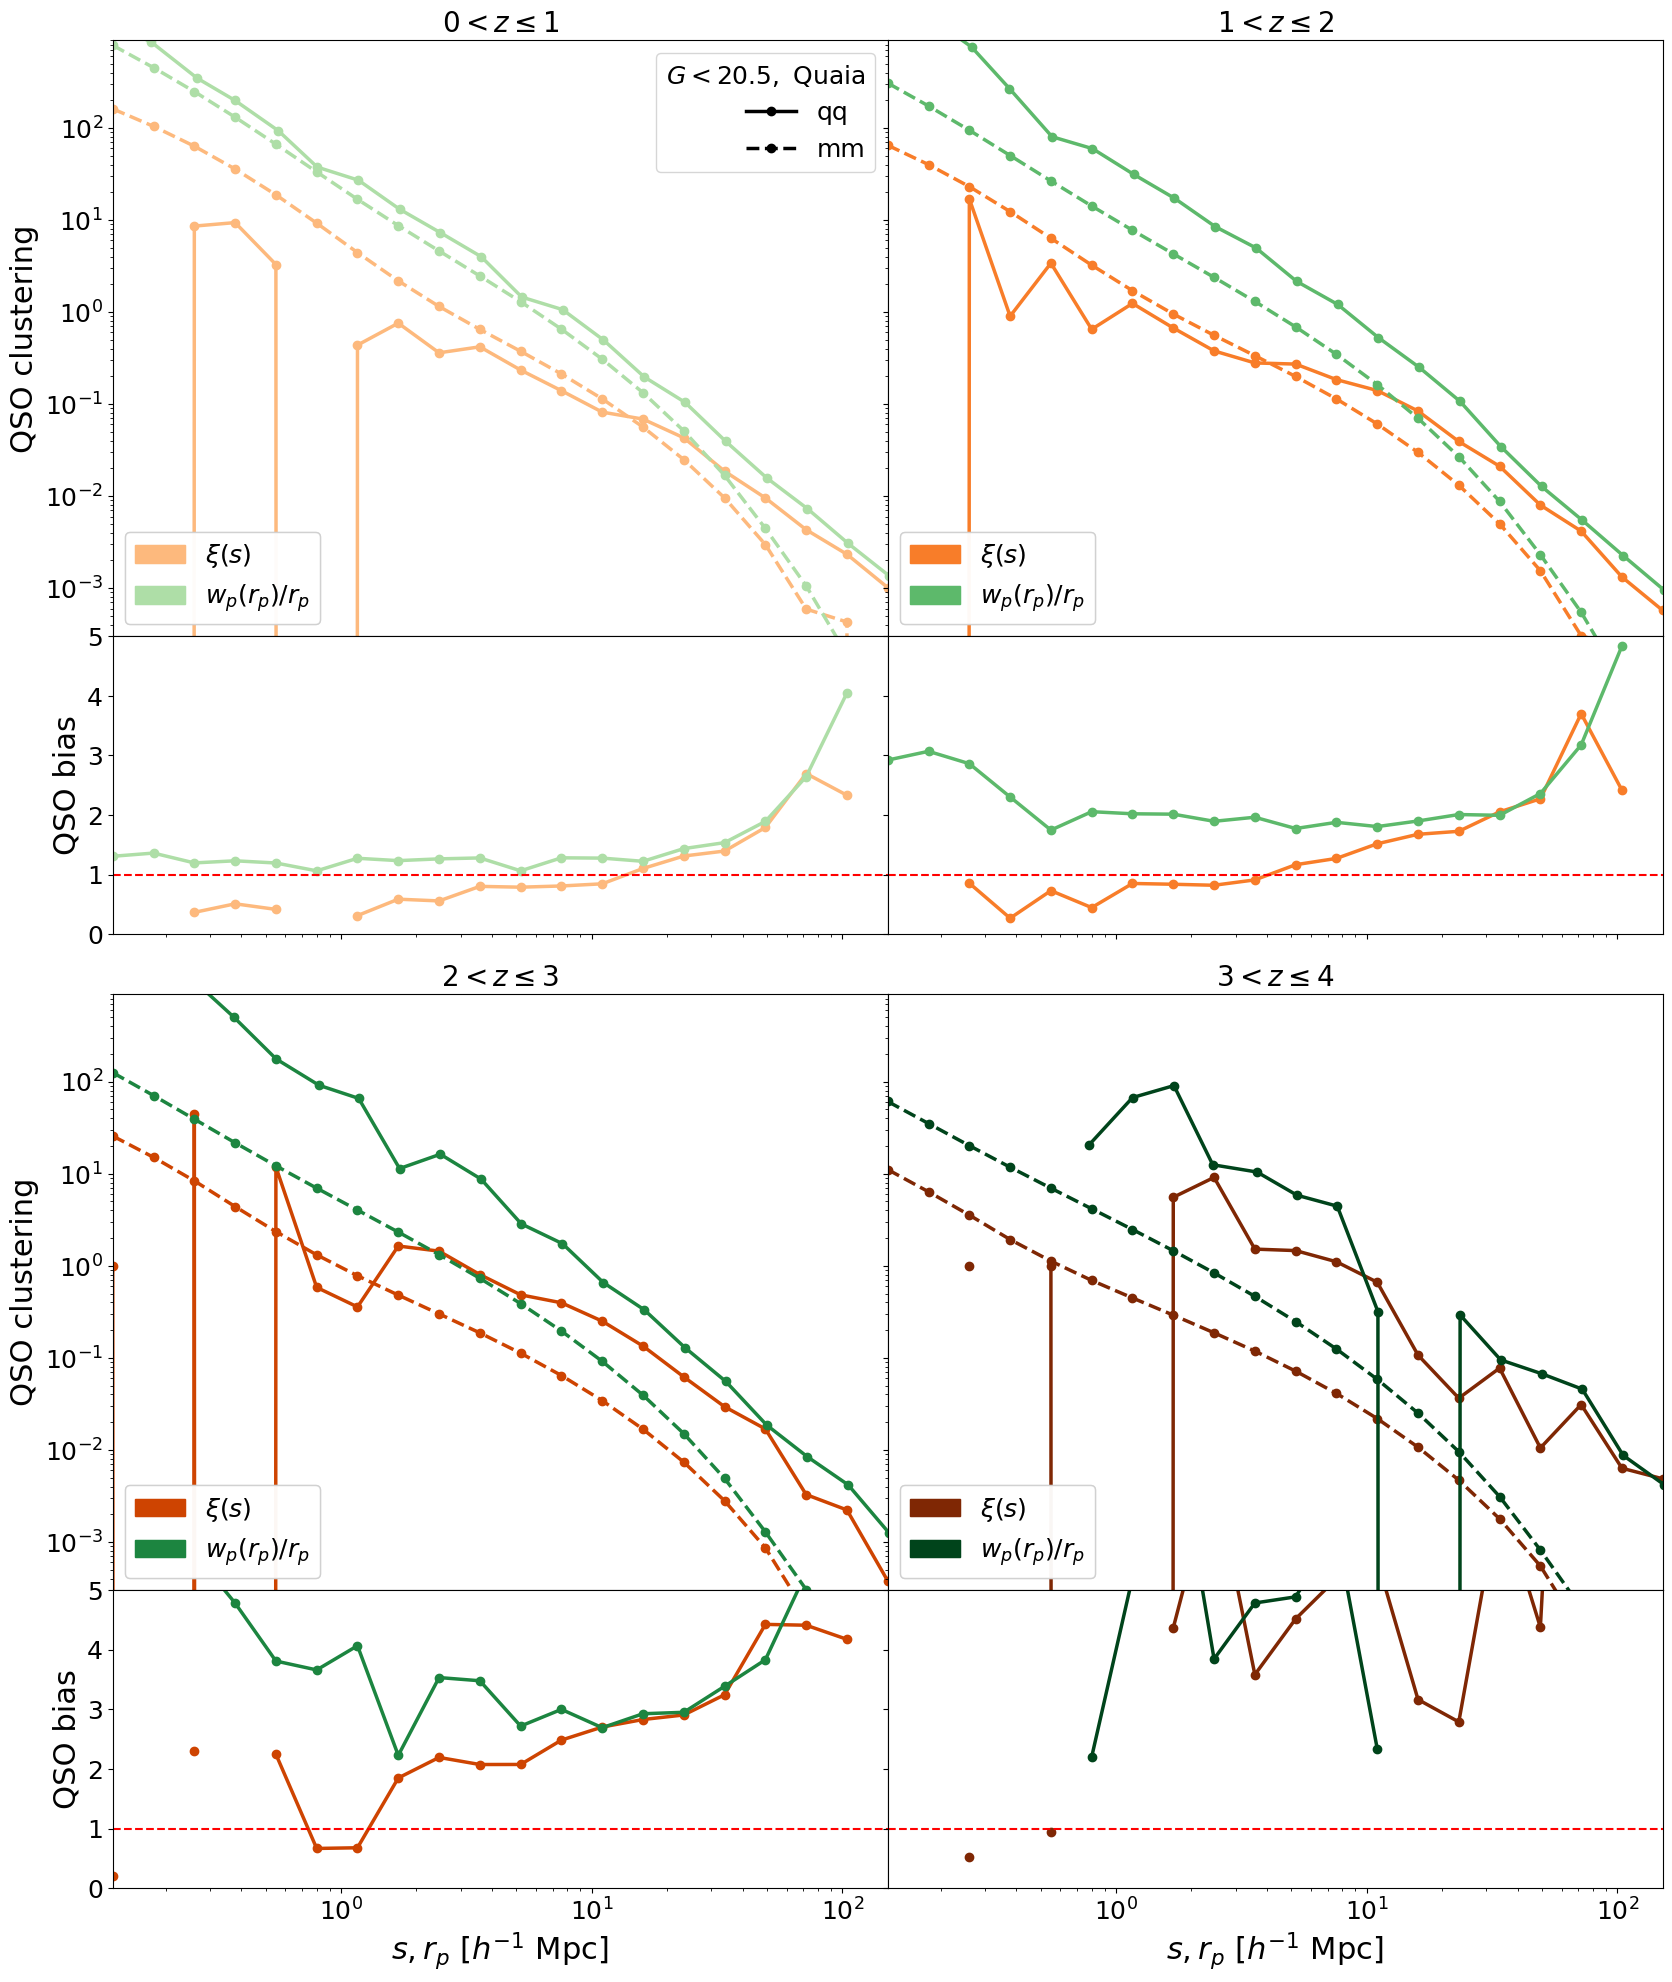

In [34]:
# labels = ['Corrfunc', 'Quaia']
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.plot(quaia.recenter(rbins), cf_zbin[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], linestyle = '--')

        ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin[labels[i]][j]/cf_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
        
        #wp
        ax1.plot(rpavg_zbin[labels[i]][j], wp_zbin[labels[i]][j]/rpavg_zbin[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_mm[j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], linestyle = '--')

        ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin[labels[i]][j]/wp_matter_zbin[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    # plt.suptitle(labels[i], fontsize = 22, y = 0.92)
    plt.show()

# Use a 50th percentile mask
## For $\xi(s)$

In [35]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

cf_zbin_percentile, cf_matter_zbin_percentile = {label: [] for label in labels}, {label: [] for label in labels}
for i in range(len(Omega_m_array)):
    
    for j in z_array:

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                         bins = [z_bins], tab_gcat_type = 'data',
                                                                                         method = ['minmax'], fac_rand = 25,
                                                                                         n_bins = [None], mask = mask*100, percentile = True)
        cf_zbin_percentile[labels[i]].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                   rbins = rbins, Om0 = Omega_m_array[i], h = h_array[i]))

        H0 = h_array[i]*100 * u.km/u.s/u.Mpc
        rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

        cf_matter_zbin_percentile[labels[i]].append(ccl.correlations.correlation_3d(cosmos[i], r=rbins_Mpc, a=a_median(tab_datahi_mask_zbin0)))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


...

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/2625073152.py:15: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/2625073152.py:15: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/2625073152.py:15: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), colo

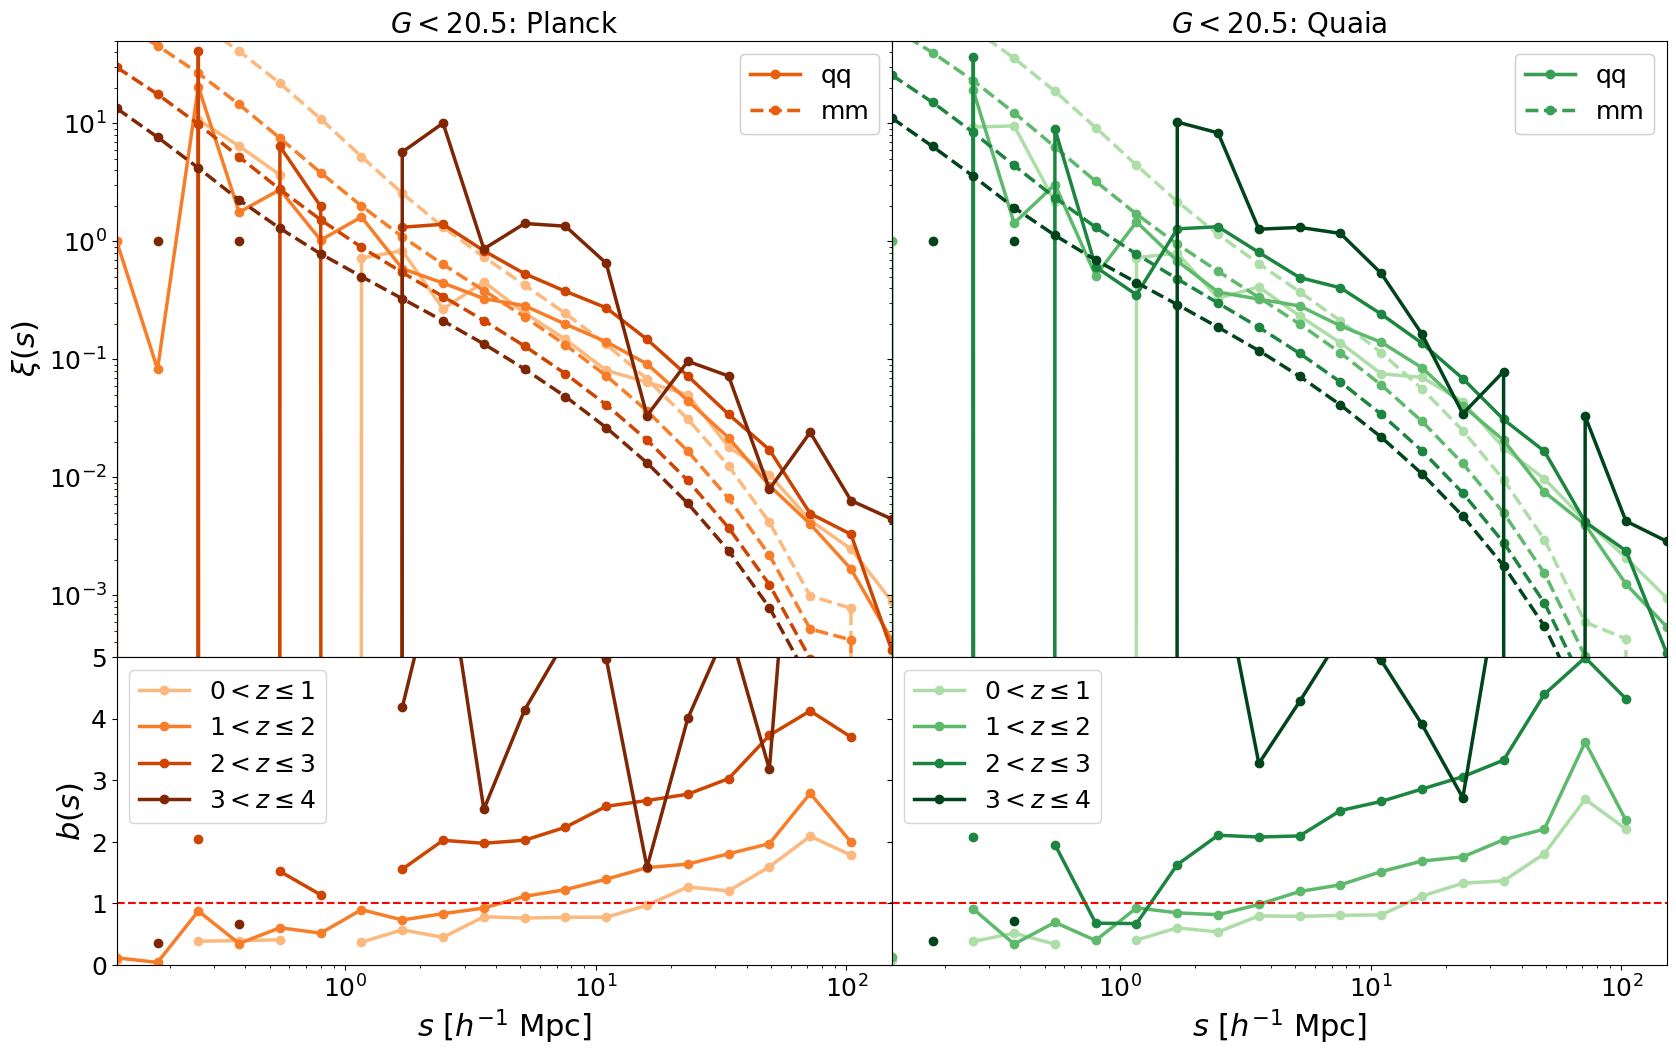

In [36]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        ax1.plot(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/3023590382.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/3023590382.py:20: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_157745/3023590382.py:17: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/3023590382.py:

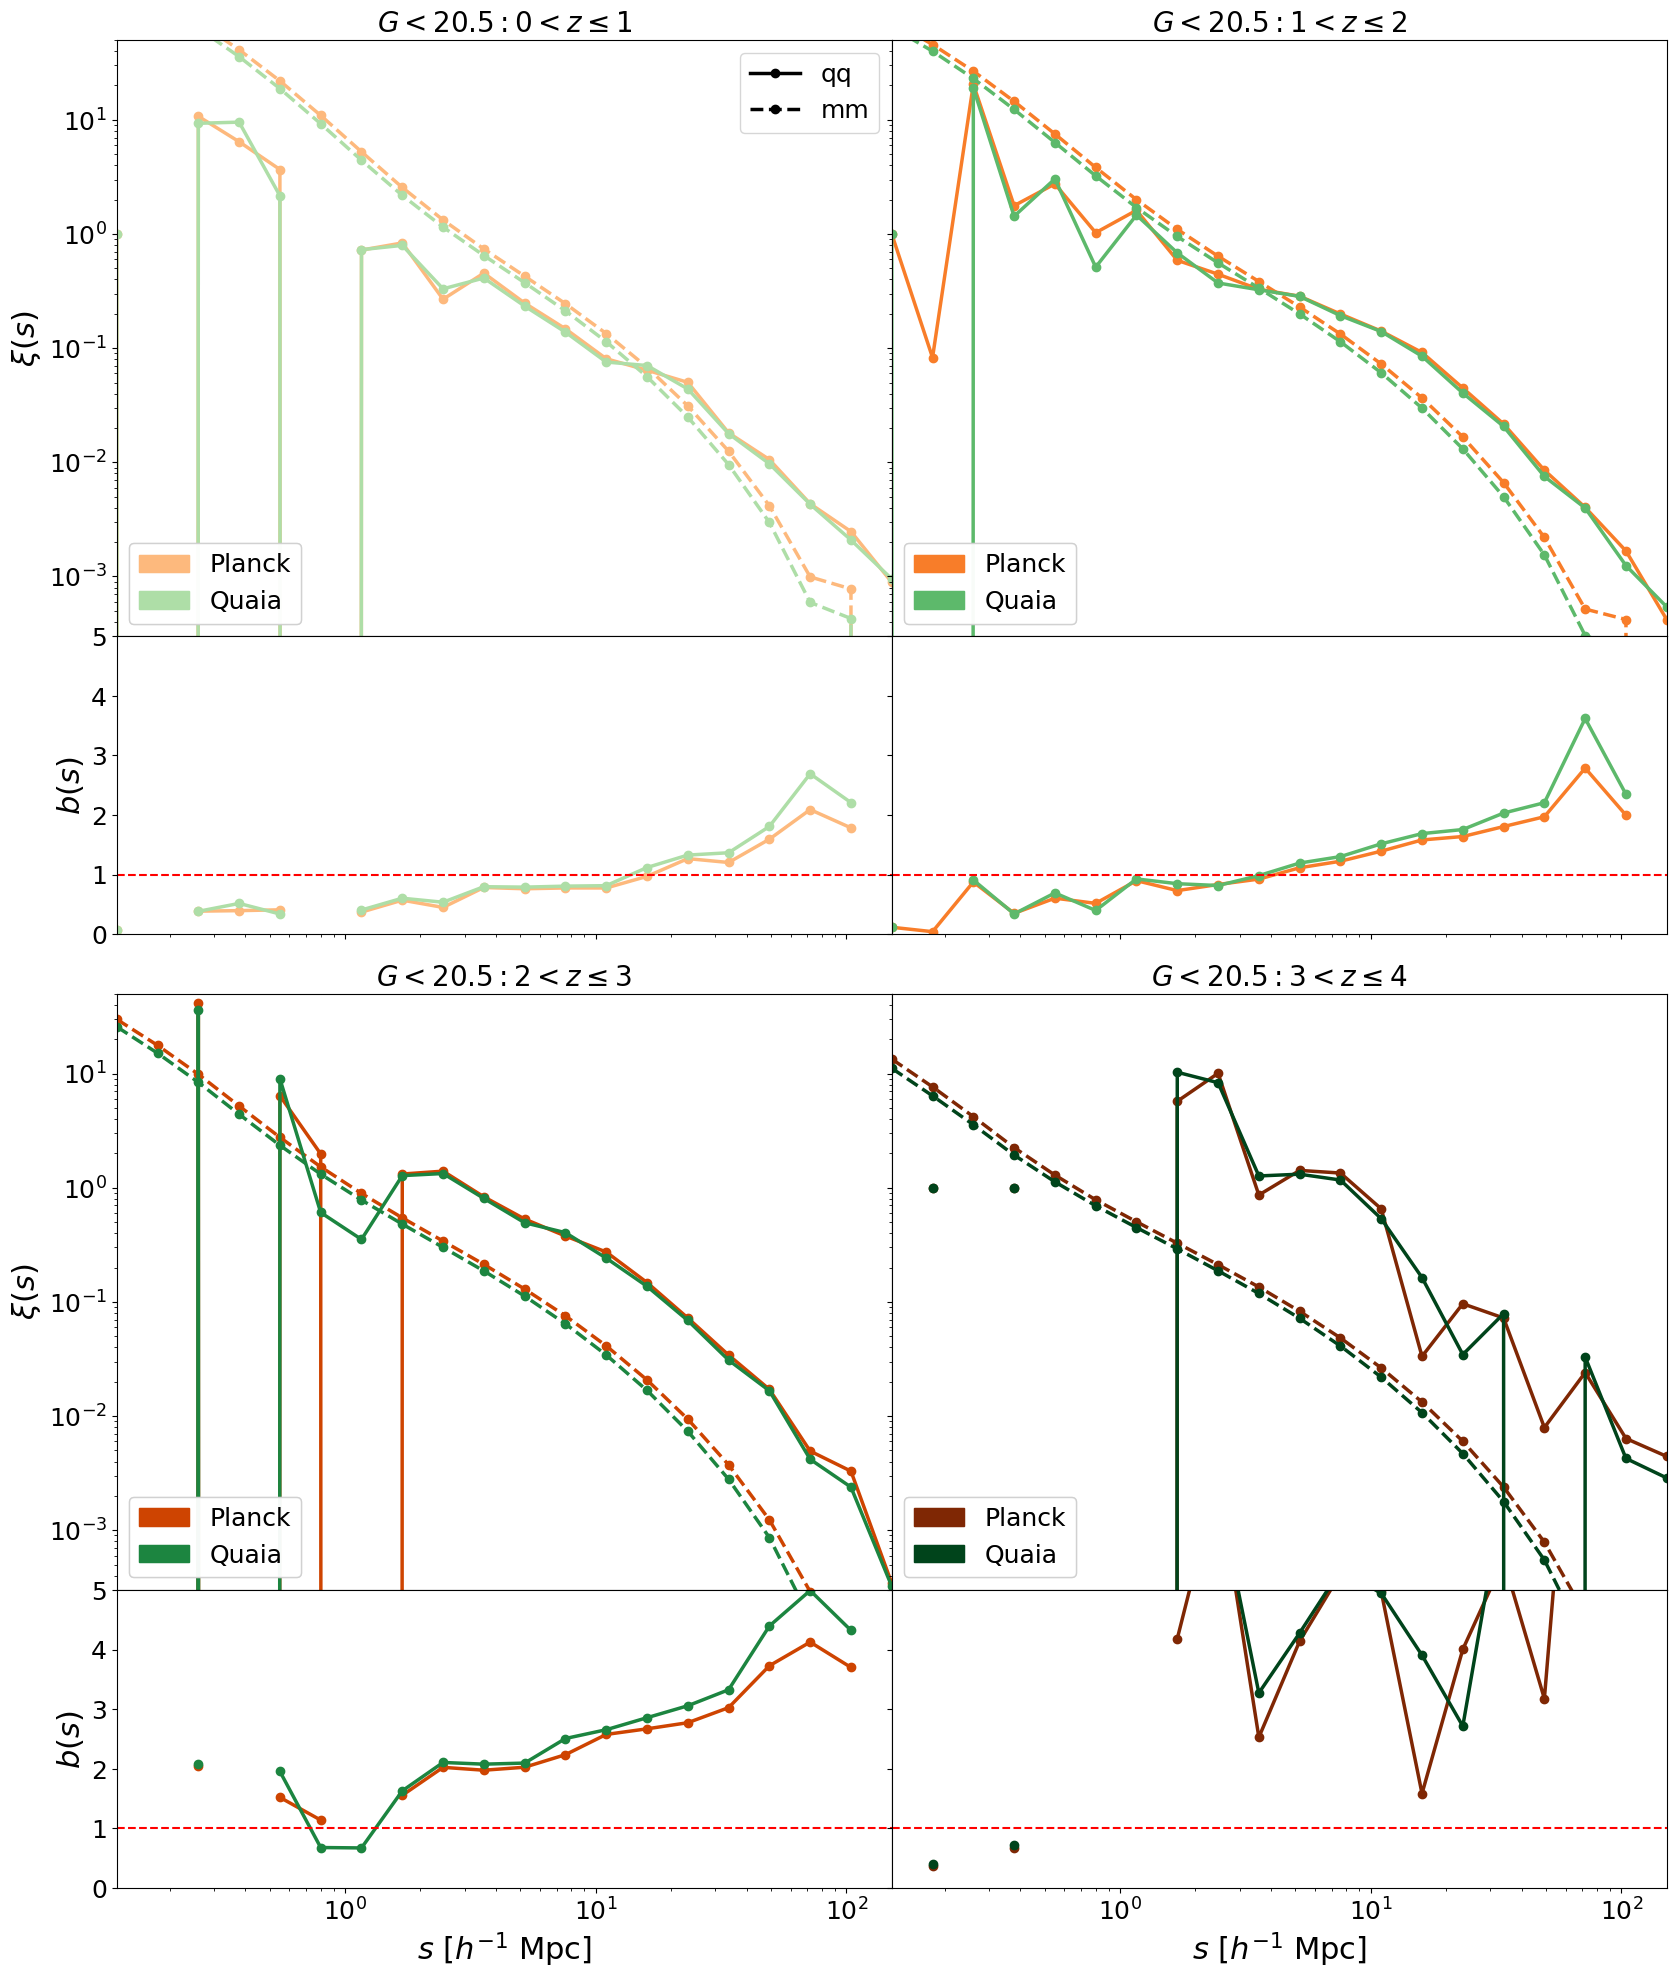

In [37]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    for i in range(len(Omega_m_array)):
    
        ax1.plot(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
                              # , title = 'Cosmology', title_fontsize = 18)
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)
    # ax2.legend()

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

## For $w_p(r_p)$

In [38]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

wp_zbin_percentile, wp_matter_zbin_percentile = {label: [] for label in labels}, {label: [] for label in labels}
rpavg_zbin_percentile = {label: [] for label in labels}
for i in range(len(Omega_m_array)):
    
    for j in z_array:
    
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                         bins = [z_bins], tab_gcat_type = 'data',
                                                                                         method = ['minmax'], fac_rand = 25,
                                                                                         n_bins = [None], mask = mask)
        wp_zbin_i, rpavg_zbin_i = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, Om0 = Omega_m_array[i], h = h_array[i],
                                                          nthreads = nthreads, rbins = rpbins, nbins = nbins, pimax = pimax)
        wp_zbin_percentile[labels[i]].append(wp_zbin_i)
        rpavg_zbin_percentile[labels[i]].append(rpavg_zbin_i)

        # version 3
        s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0_array[i]))
        
        xirppi_zbin_i = ccl.correlations.correlation_3d(cosmos[i], r=np.ravel(s_Mpc), a=a_median(tab_datahi_mask_zbin0))
        wp_matter_zbin_percentile[labels[i]].append(2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0))

G20.5_zmin0.0zmax1.0: 0.22              253398 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0: 0.17              536368 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508


...

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.0: 0.46              19252 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:751: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/1202227924.py:15: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin_percentile[labels[i]][j]/wp_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/1202227924.py:15: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin_percentile[labels[i]][j]/wp_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/1202227924.py:15: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin_percentile[labels[i]][j]/wp_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), c

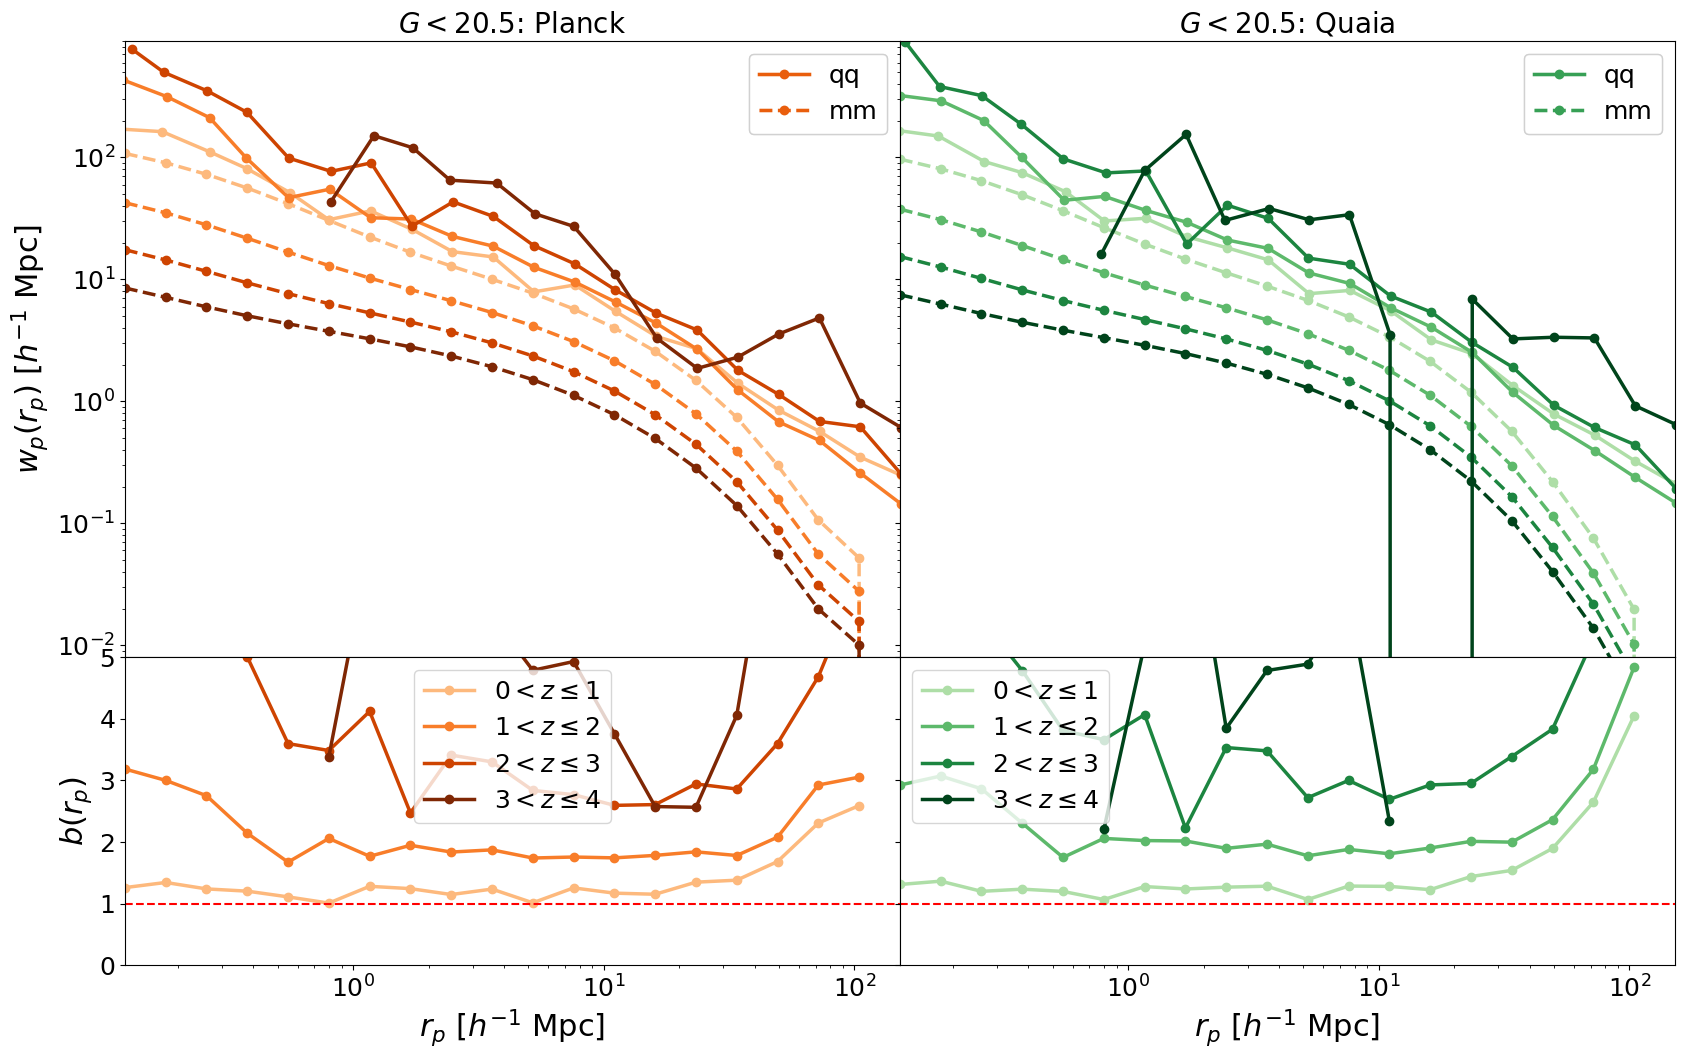

In [39]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        ax1.plot(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin_percentile[labels[i]][j]/wp_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/3520577485.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin_percentile[labels[i]][j]/wp_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/3520577485.py:20: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_157745/3520577485.py:17: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin_percentile[labels[i]][j]/wp_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/3520577485.p

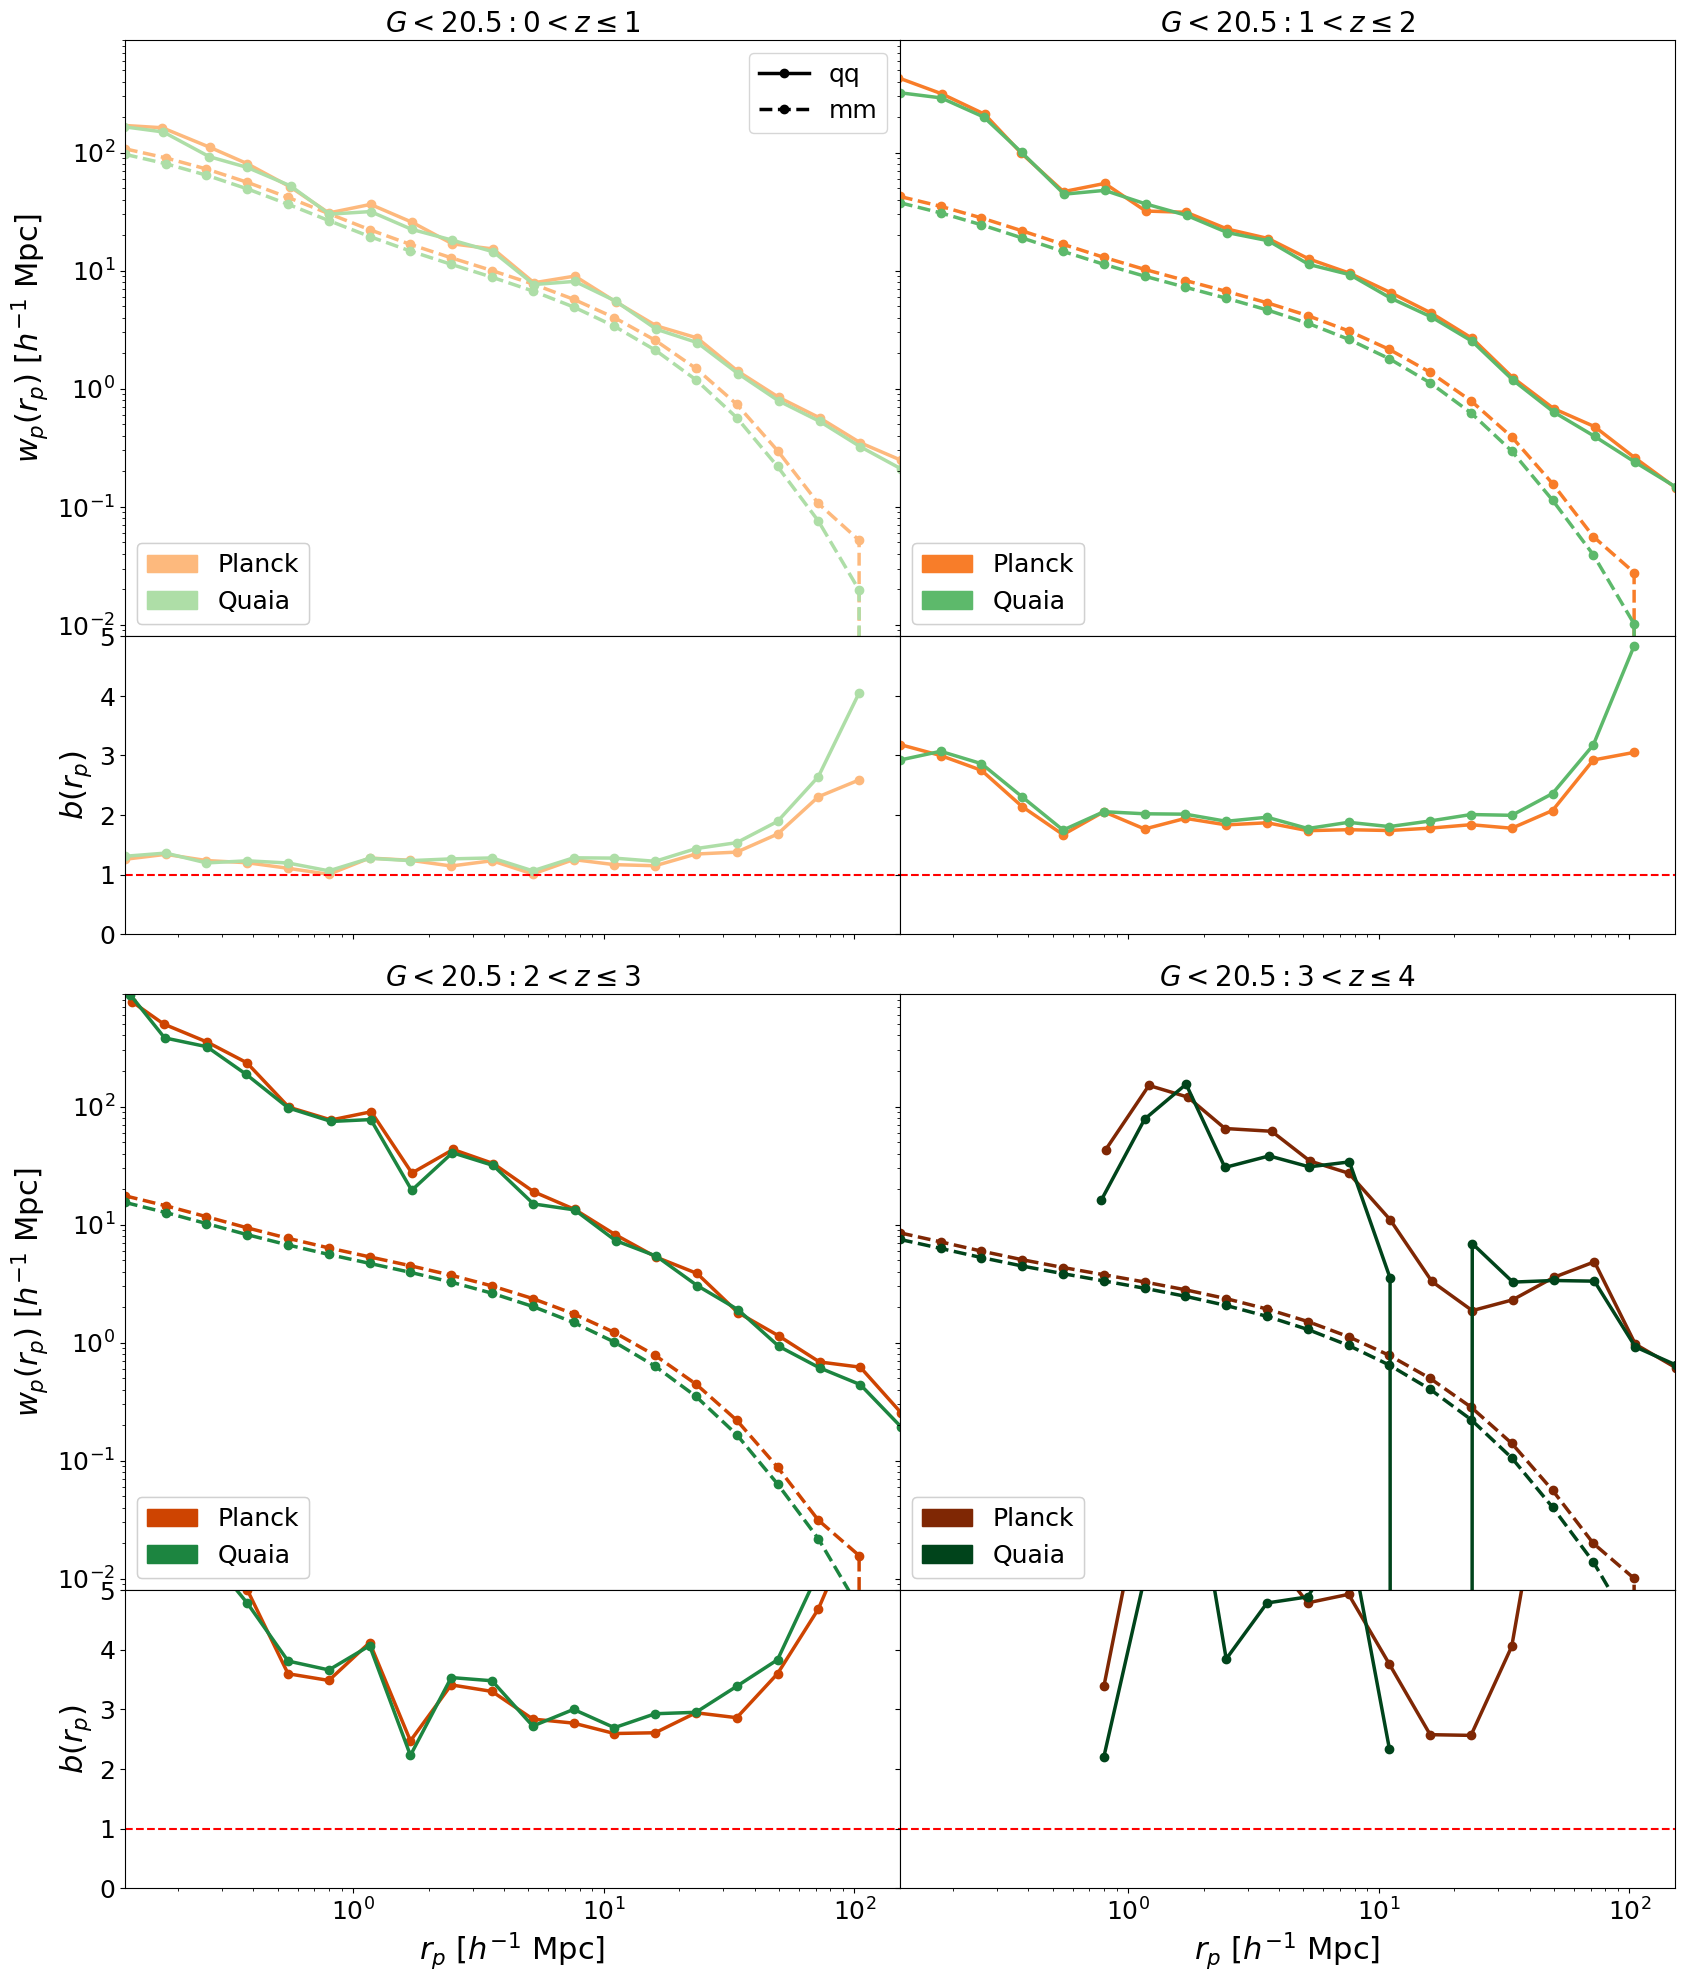

In [40]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    for i in range(len(Omega_m_array)):
    
        ax1.plot(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin_percentile[labels[i]][j]/wp_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/2429251145.py:19: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/2429251145.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin_percentile[labels[i]][j]/wp_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j])
/tmp/ipykernel_157745/2429251145.py:28: SyntaxWarning: invalid escape sequence '\l'
  ax1.set

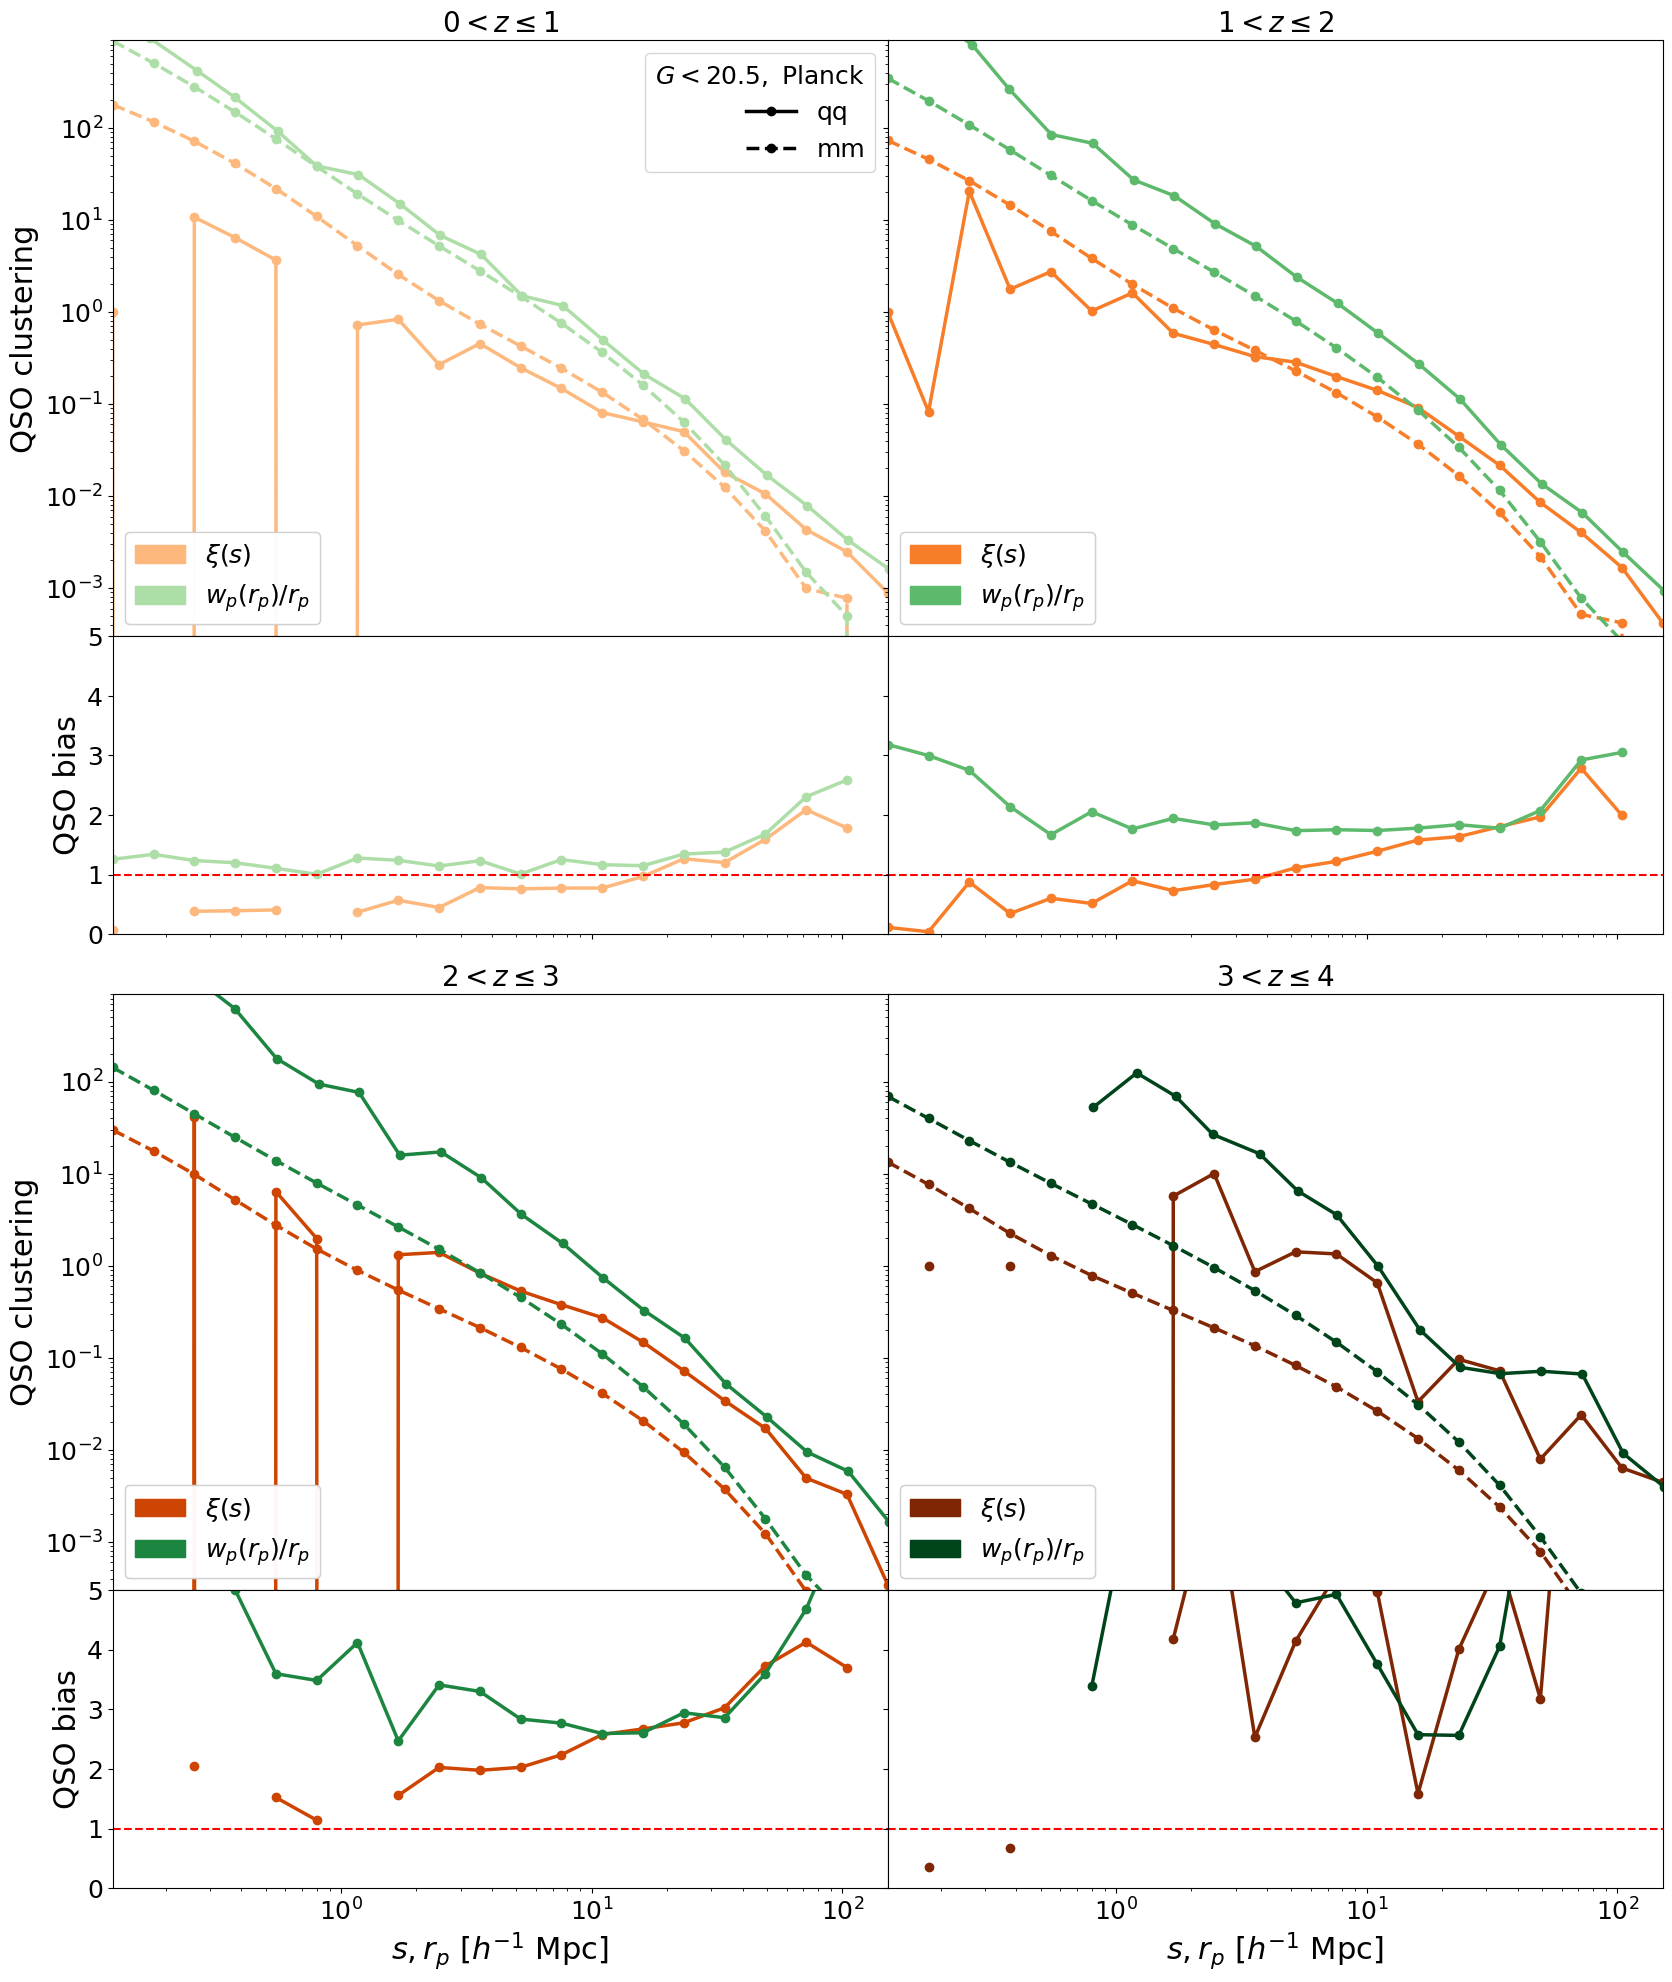

/tmp/ipykernel_157745/2429251145.py:19: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/2429251145.py:25: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin_percentile[labels[i]][j]/wp_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j])
/tmp/ipykernel_157745/2429251145.py:19: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/2429251145.py:25: RuntimeWarning: invalid value encountered

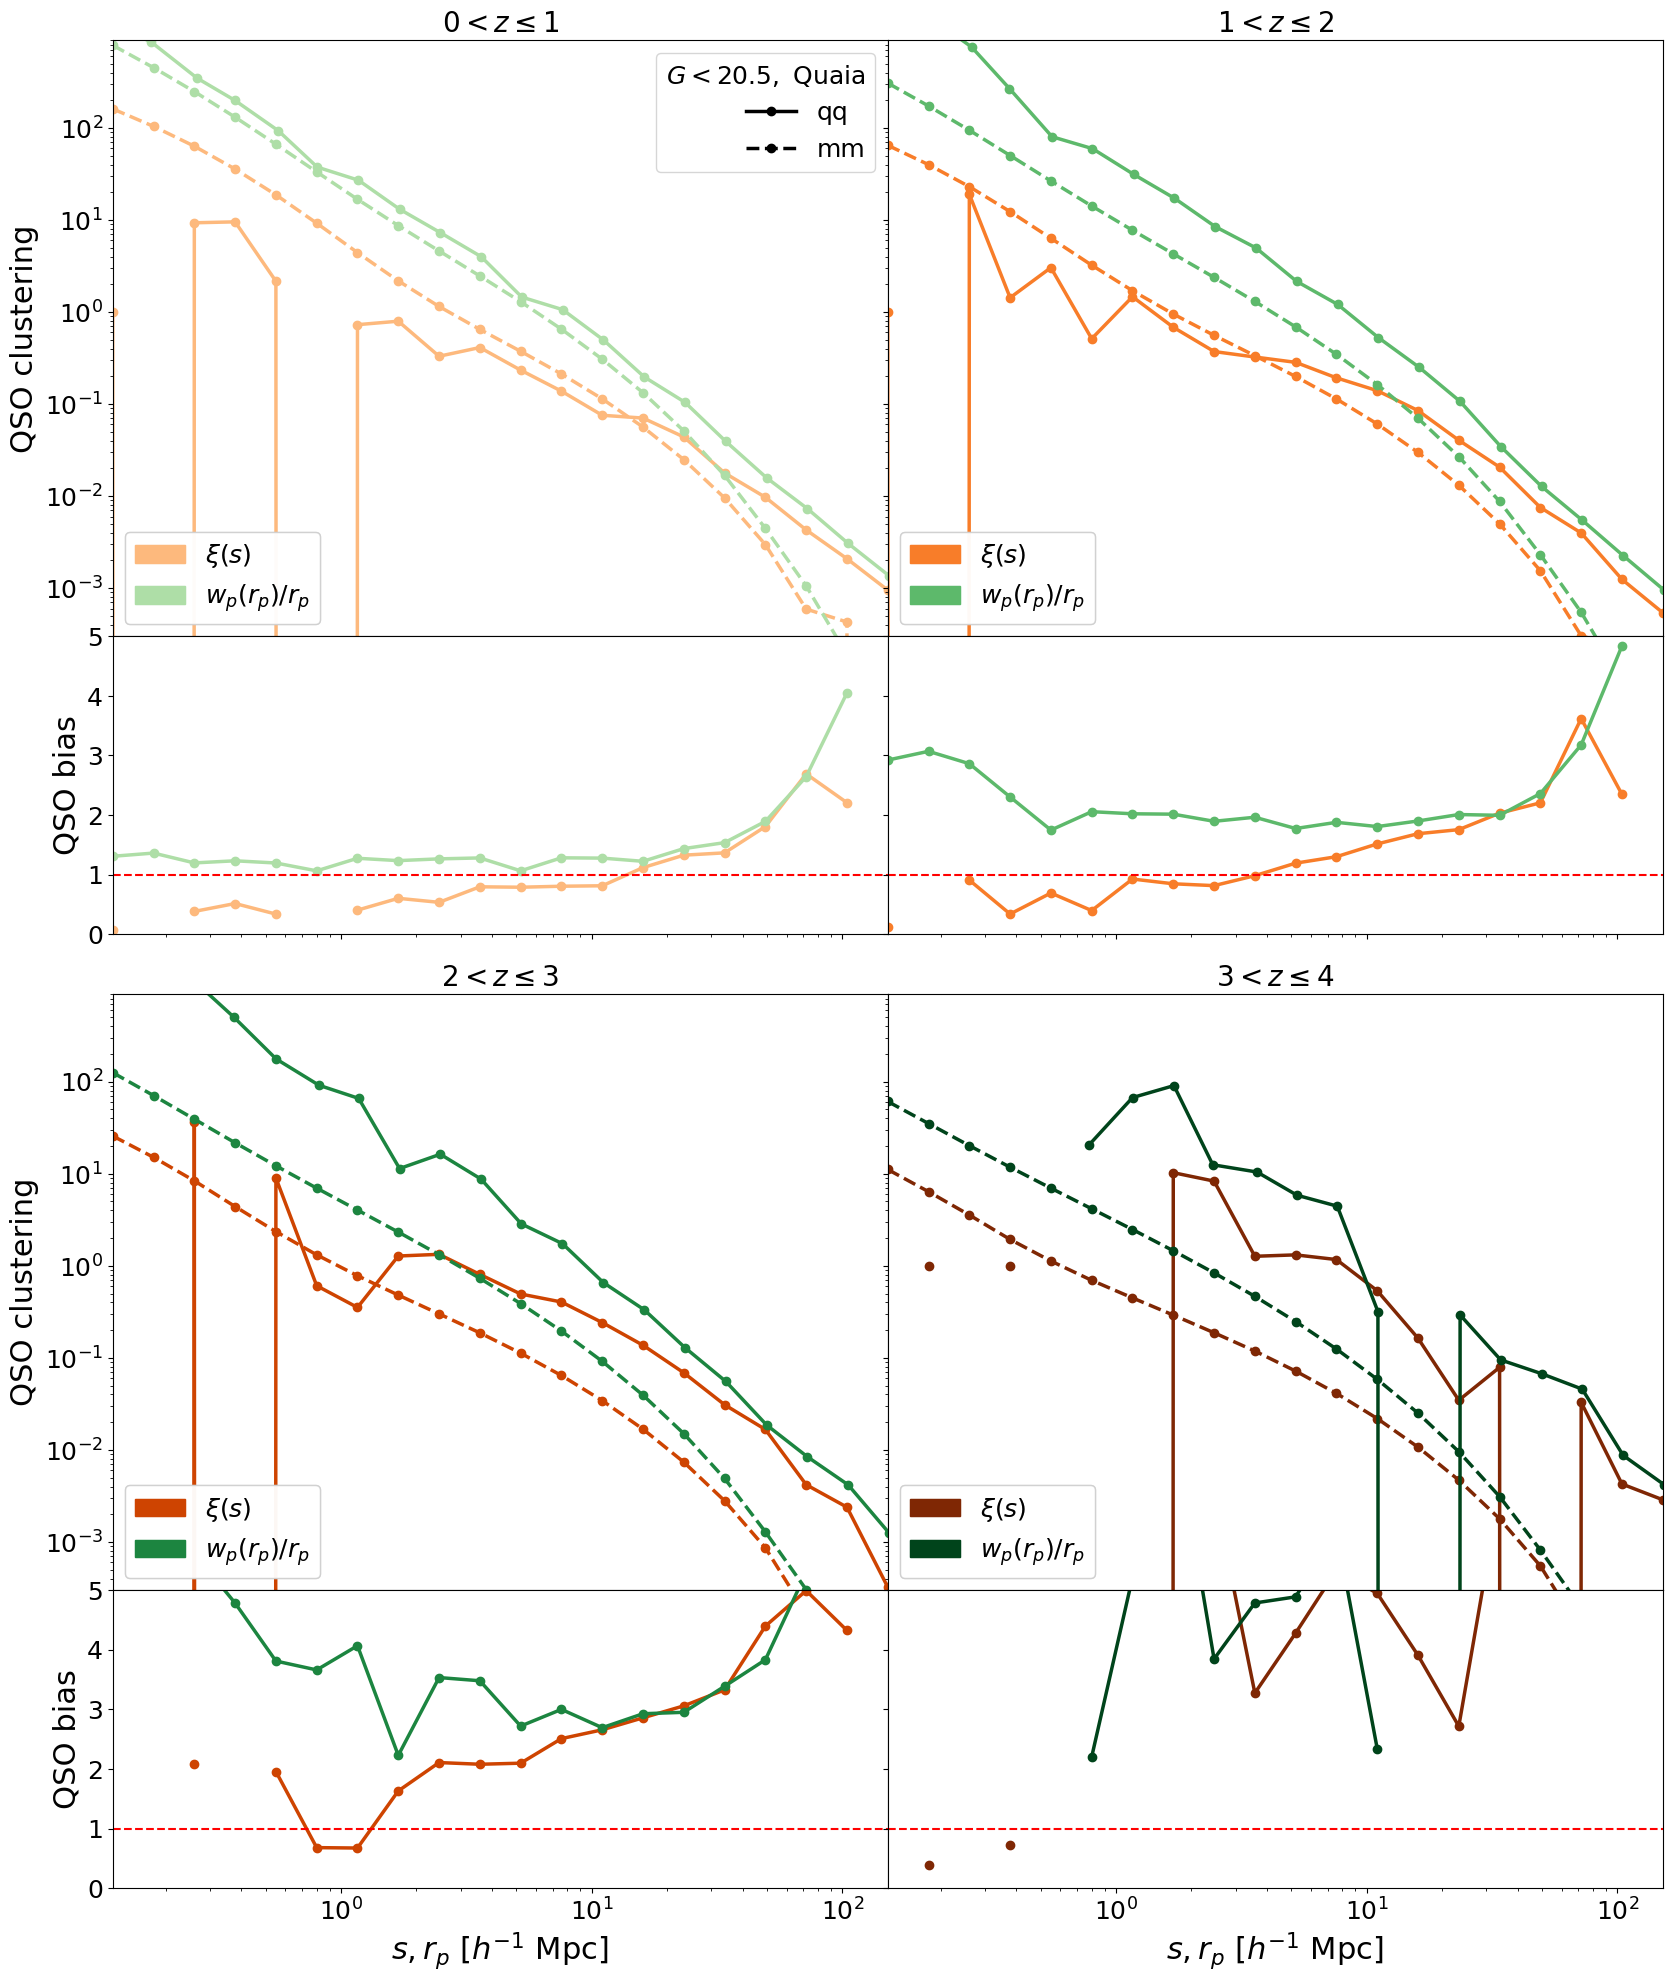

In [41]:
labels = ['Planck', 'Quaia']
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.plot(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], linestyle = '--')

        ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
        
        #wp
        ax1.plot(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j]/rpavg_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_mm[j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], linestyle = '--')

        ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_zbin_percentile[labels[i]][j]/wp_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    plt.show()

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^s_{\mathrm{qq}}(s)}{\xi^r_\mathrm{mm}(s)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

In [42]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

a_zbin = {label: [] for label in labels}
for i in range(len(Omega_m_array)):
    
    for j in z_array:

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                         bins = [z_bins], tab_gcat_type = 'data',
                                                                                         method = ['minmax'], fac_rand = 25,
                                                                                         n_bins = [None], mask = mask*100, percentile = True)
        a_zbin[labels[i]].append(a_median(tab_datahi_mask_zbin0))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336
G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196
G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508
G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630
G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336
G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196
G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508
G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/1990901748.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rbins), bias(cf_zbin_percentile[labels[i]][j], cf_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


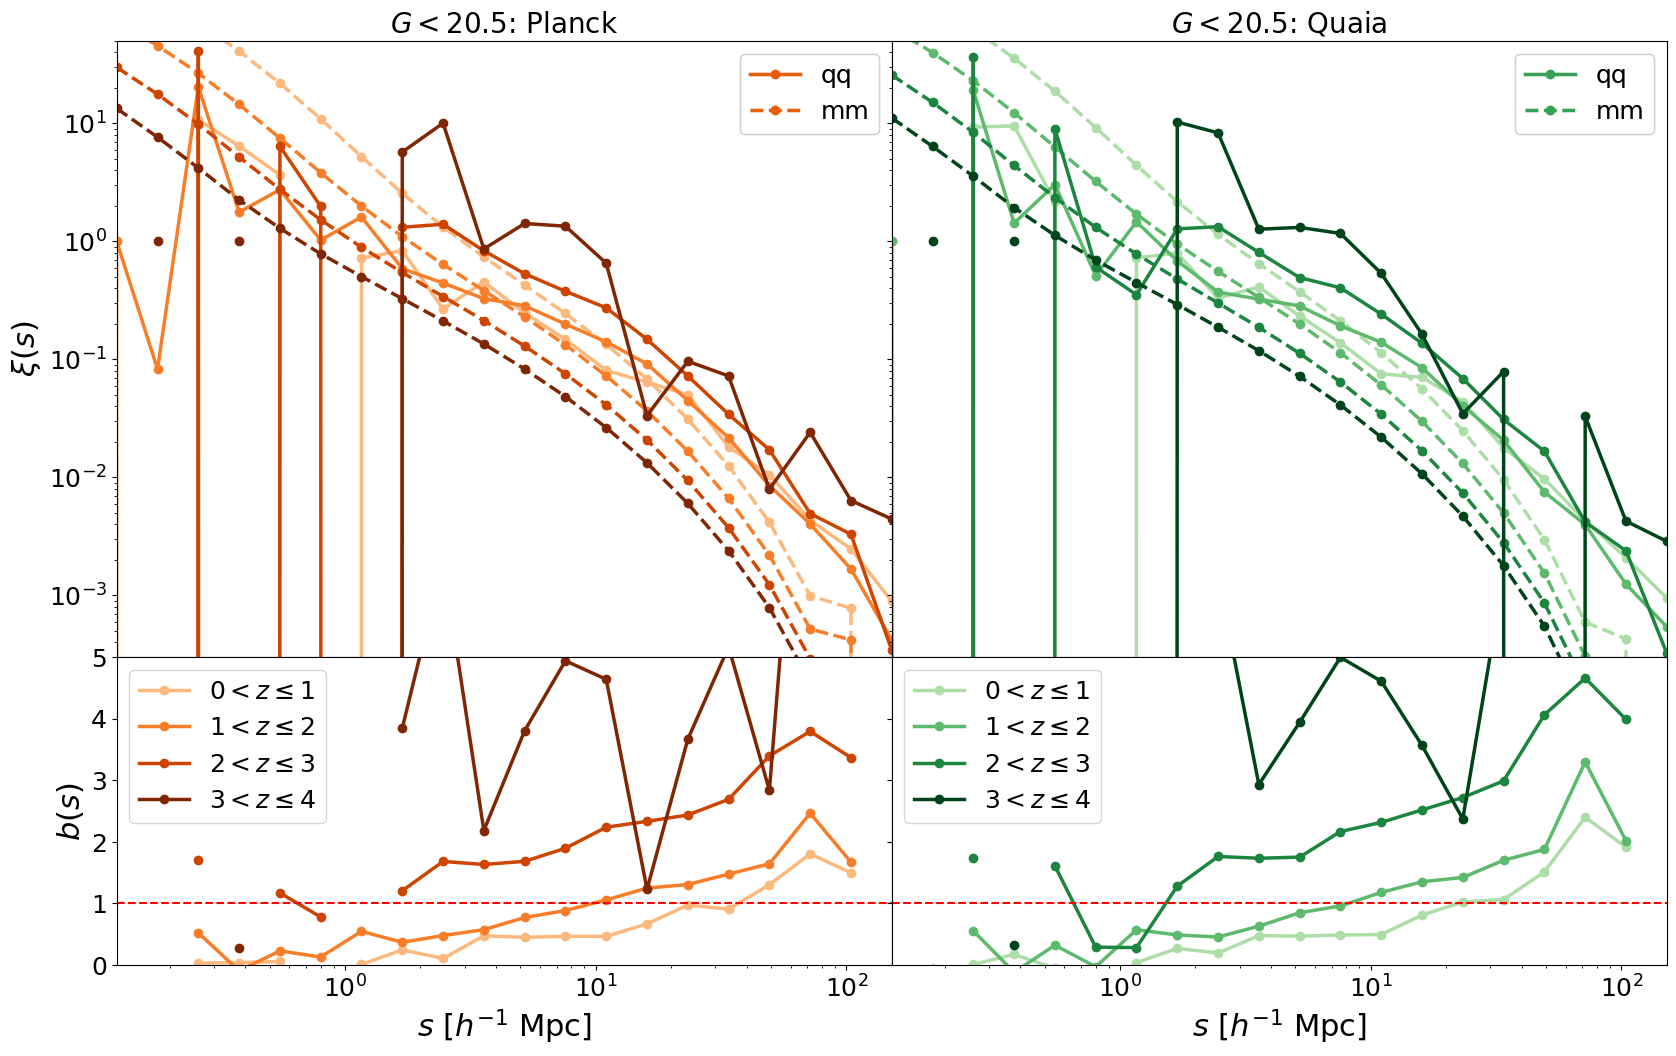

In [43]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

# labels = ['Corrfunc', 'Quaia']
labels_cf = ['qq', 'mm']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        ax1.plot(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rbins), bias(cf_zbin_percentile[labels[i]][j], cf_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/2156120861.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rbins), bias(cf_zbin_percentile[labels[i]][j], cf_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])
/tmp/ipykernel_157745/2156120861.py:20: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_157745/2473749

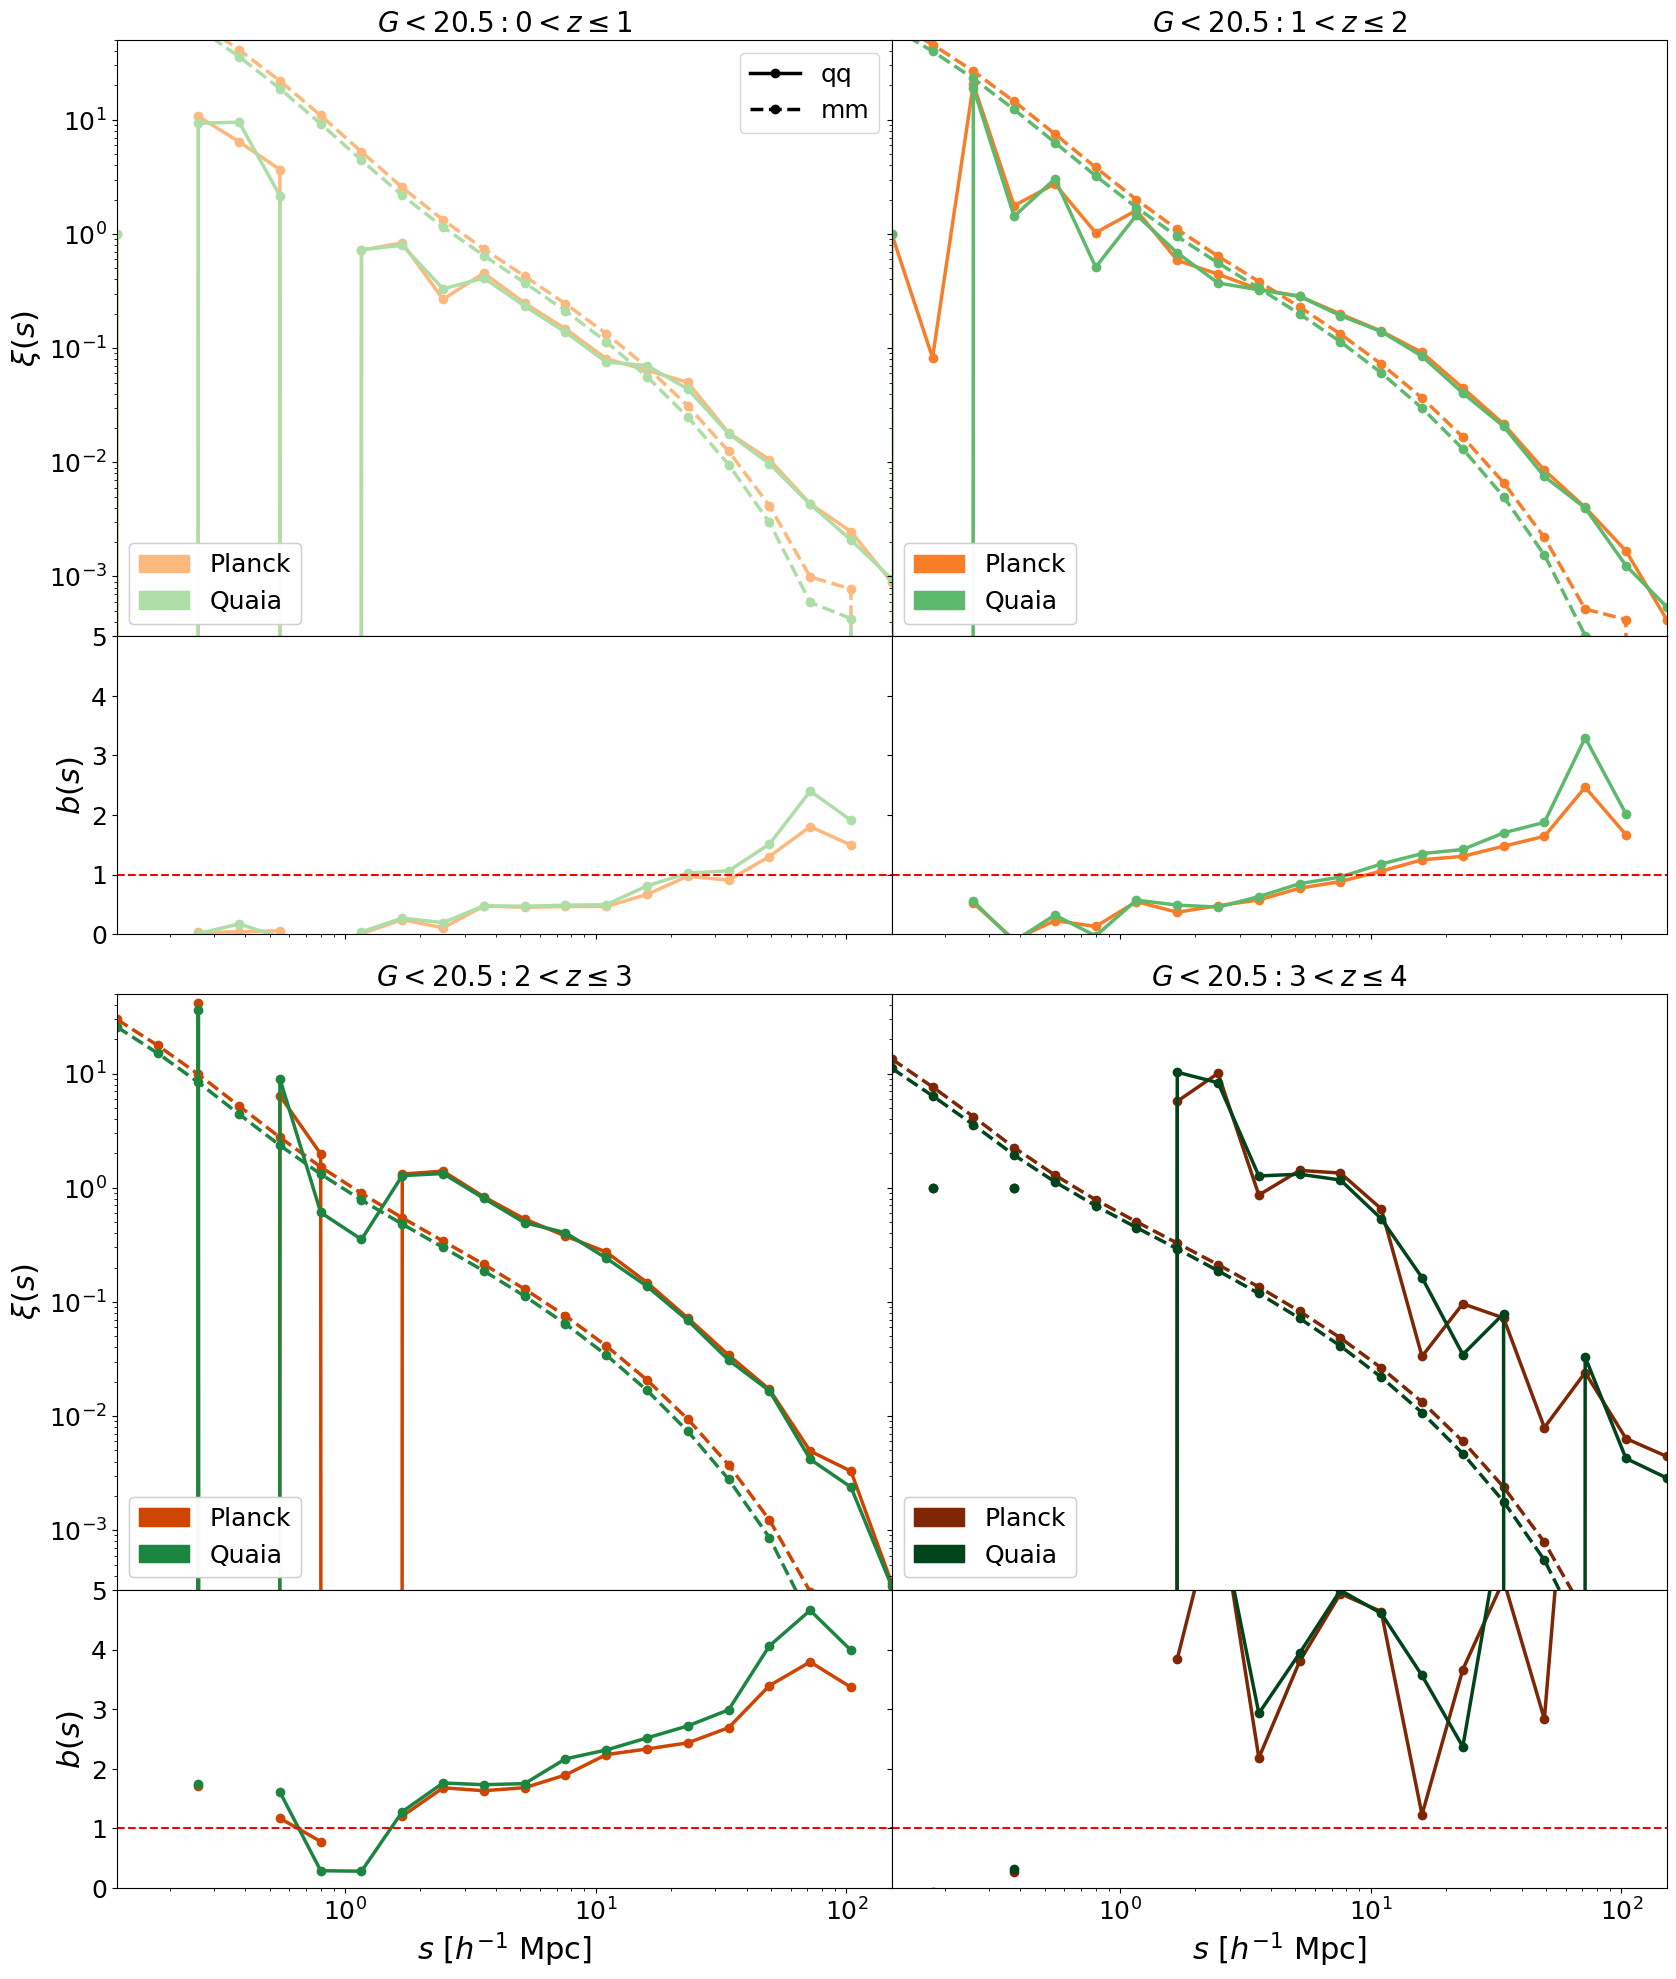

In [44]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    for i in range(len(Omega_m_array)):
    
        ax1.plot(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rbins), bias(cf_zbin_percentile[labels[i]][j], cf_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{w^s_{p,{\mathrm{qq}}(r_p)}}{w^r_{p,\mathrm{mm}}(r_p)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/1938653094.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1),
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


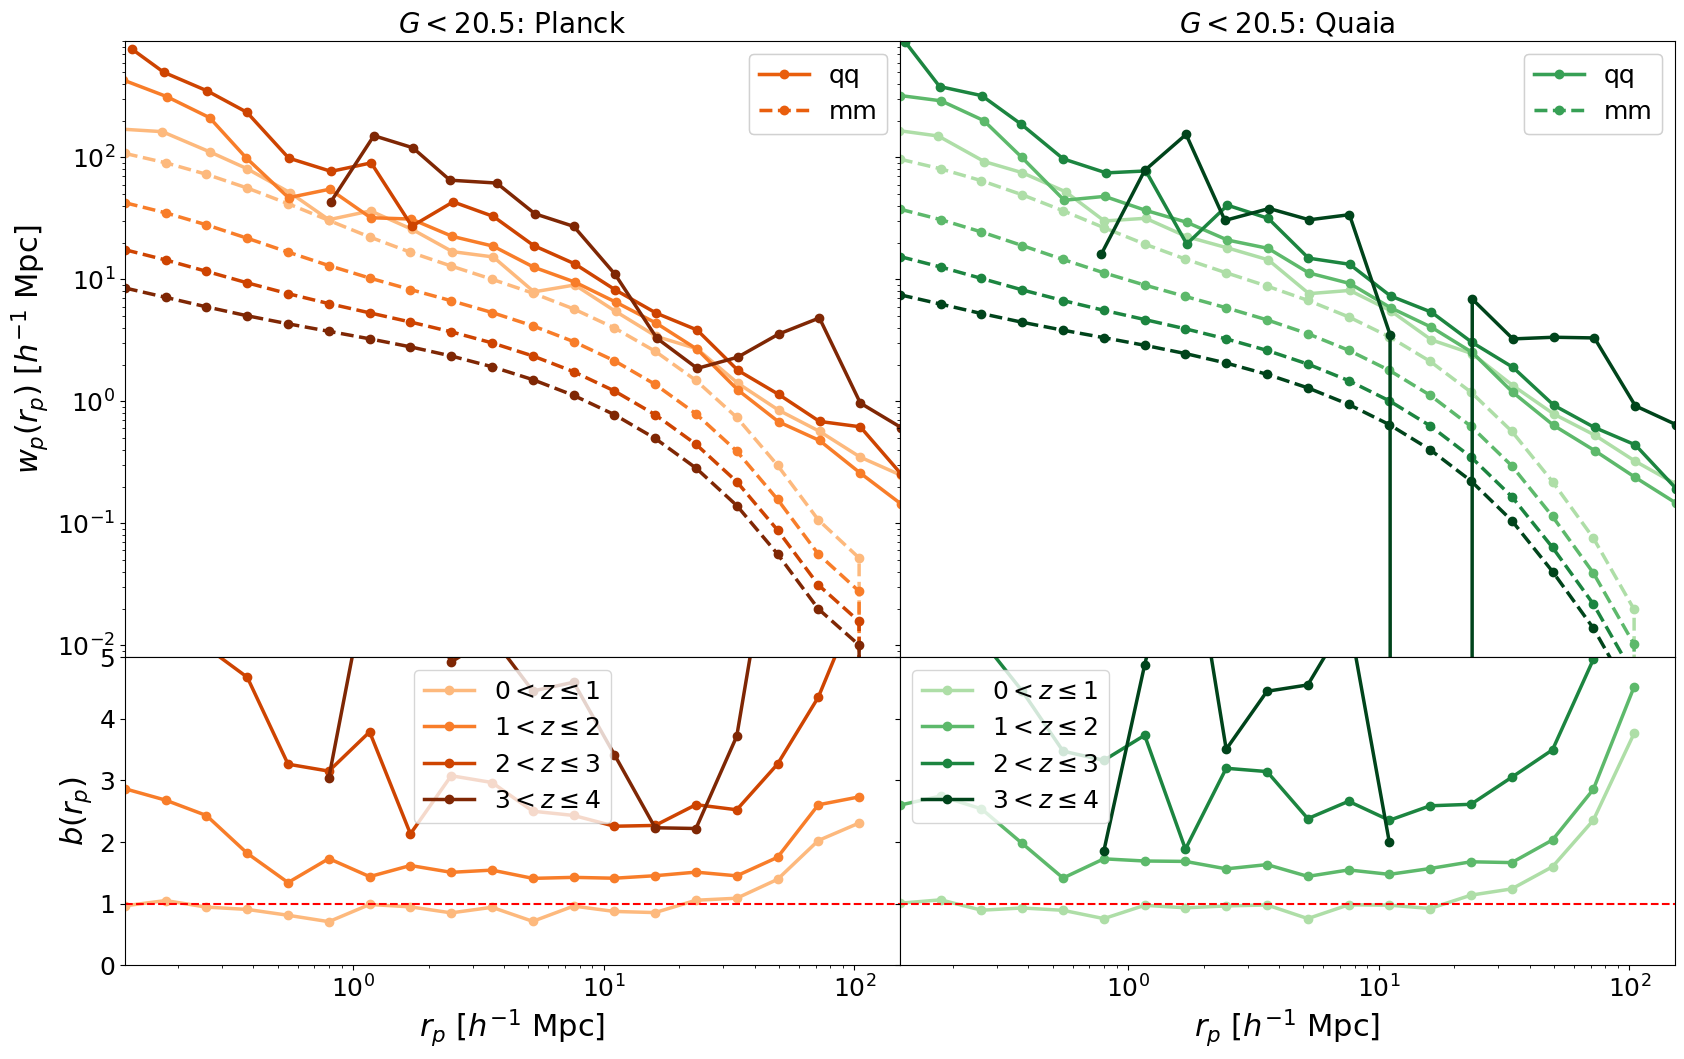

In [45]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

# labels = ['Corrfunc', 'Quaia']
labels_cf = ['qq', 'mm']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        ax1.plot(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), 
                 color = cmaps[i][j])

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/1711313309.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1),
/tmp/ipykernel_157745/1711313309.py:21: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWar

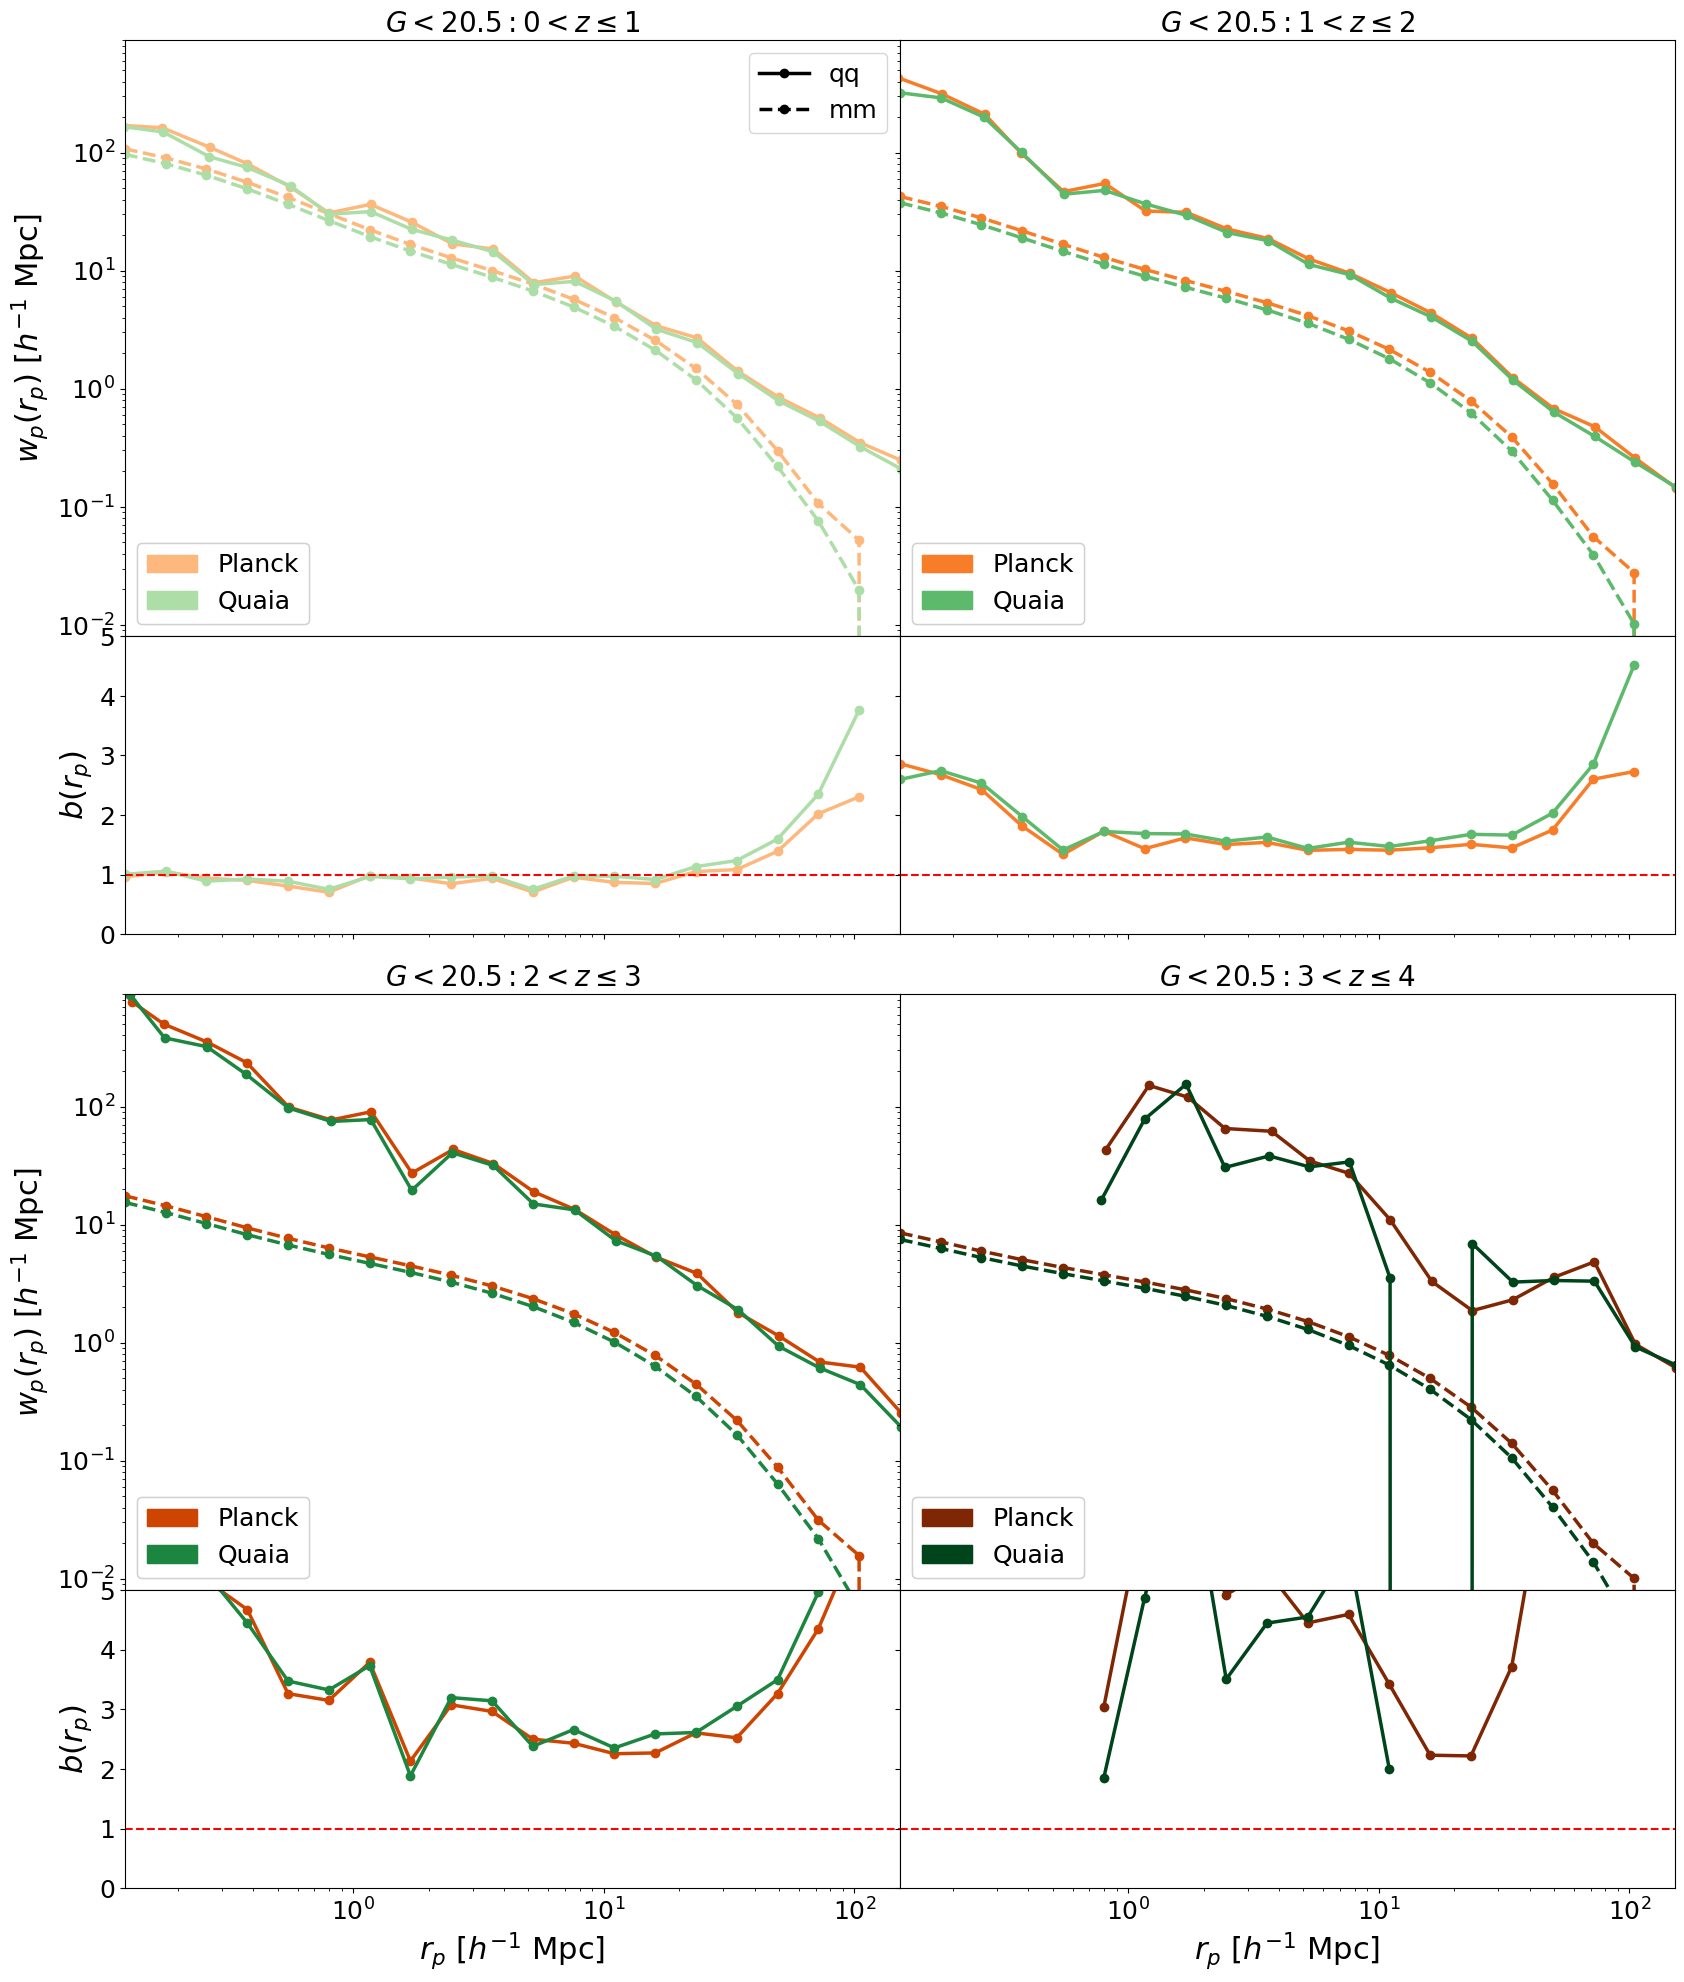

In [46]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    for i in range(len(Omega_m_array)):
    
        ax1.plot(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.plot(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), 
                 color = cmaps[i][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/3176316175.py:18: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/3176316175.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1),
/tmp/ipykernel_157745/3176316175.py:28: SyntaxWarning: invalid es

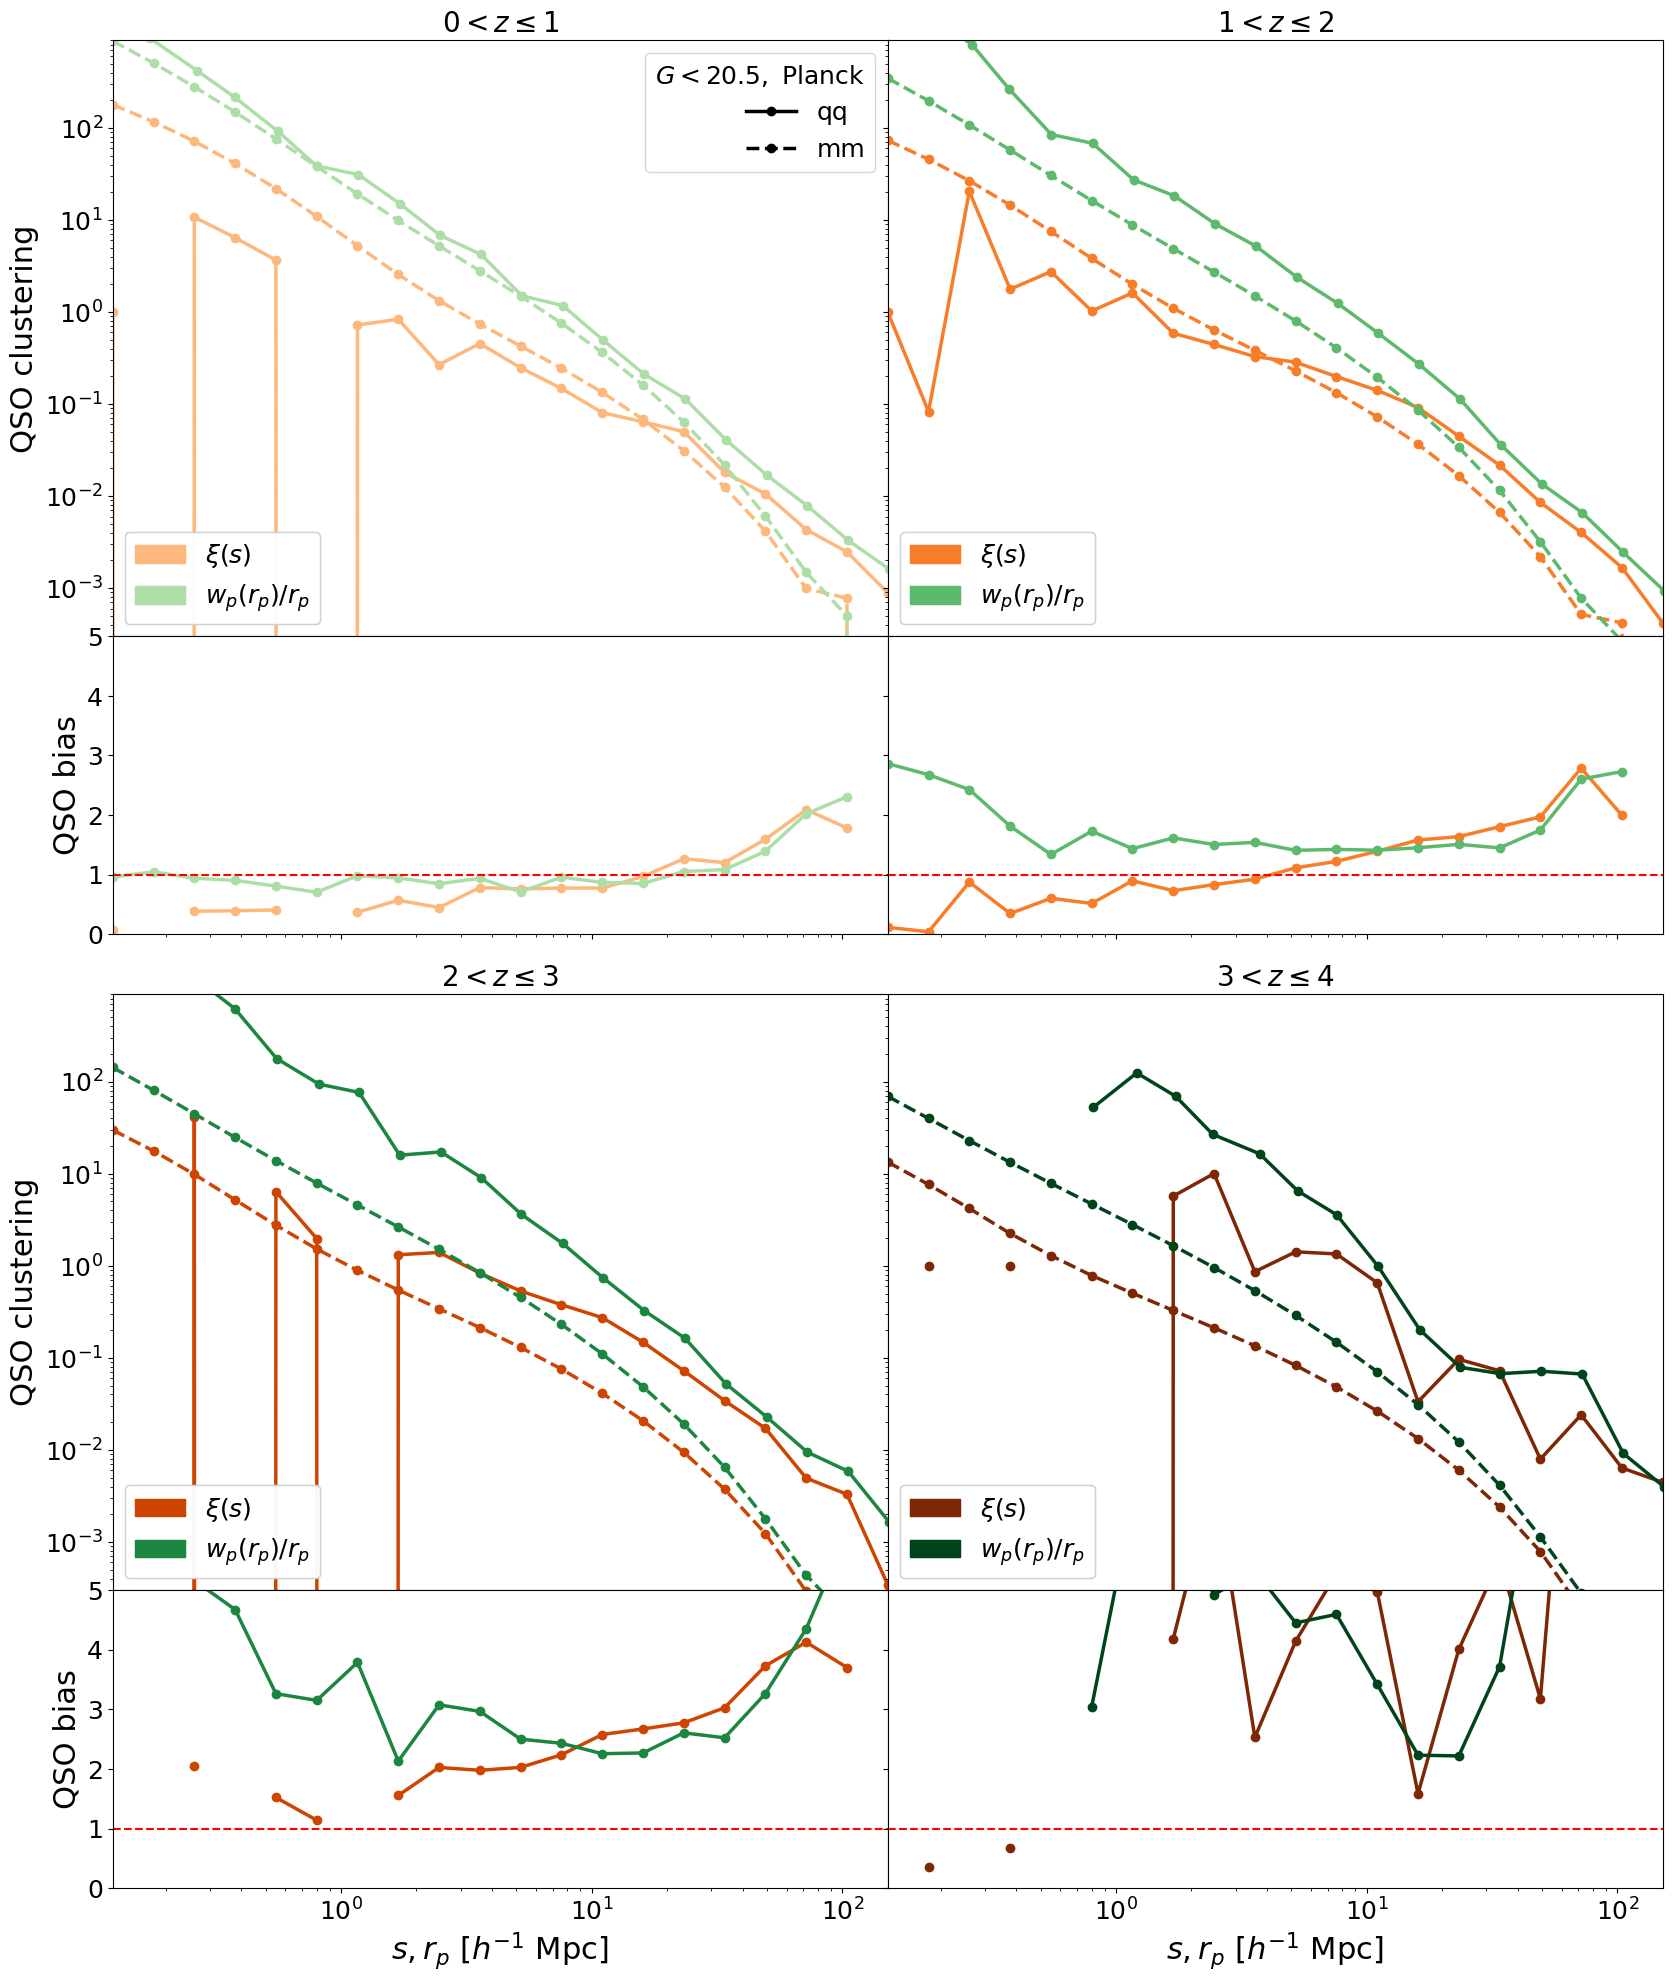

/tmp/ipykernel_157745/3176316175.py:18: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_157745/3176316175.py:18: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_157745/3176316175.py:18: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins)

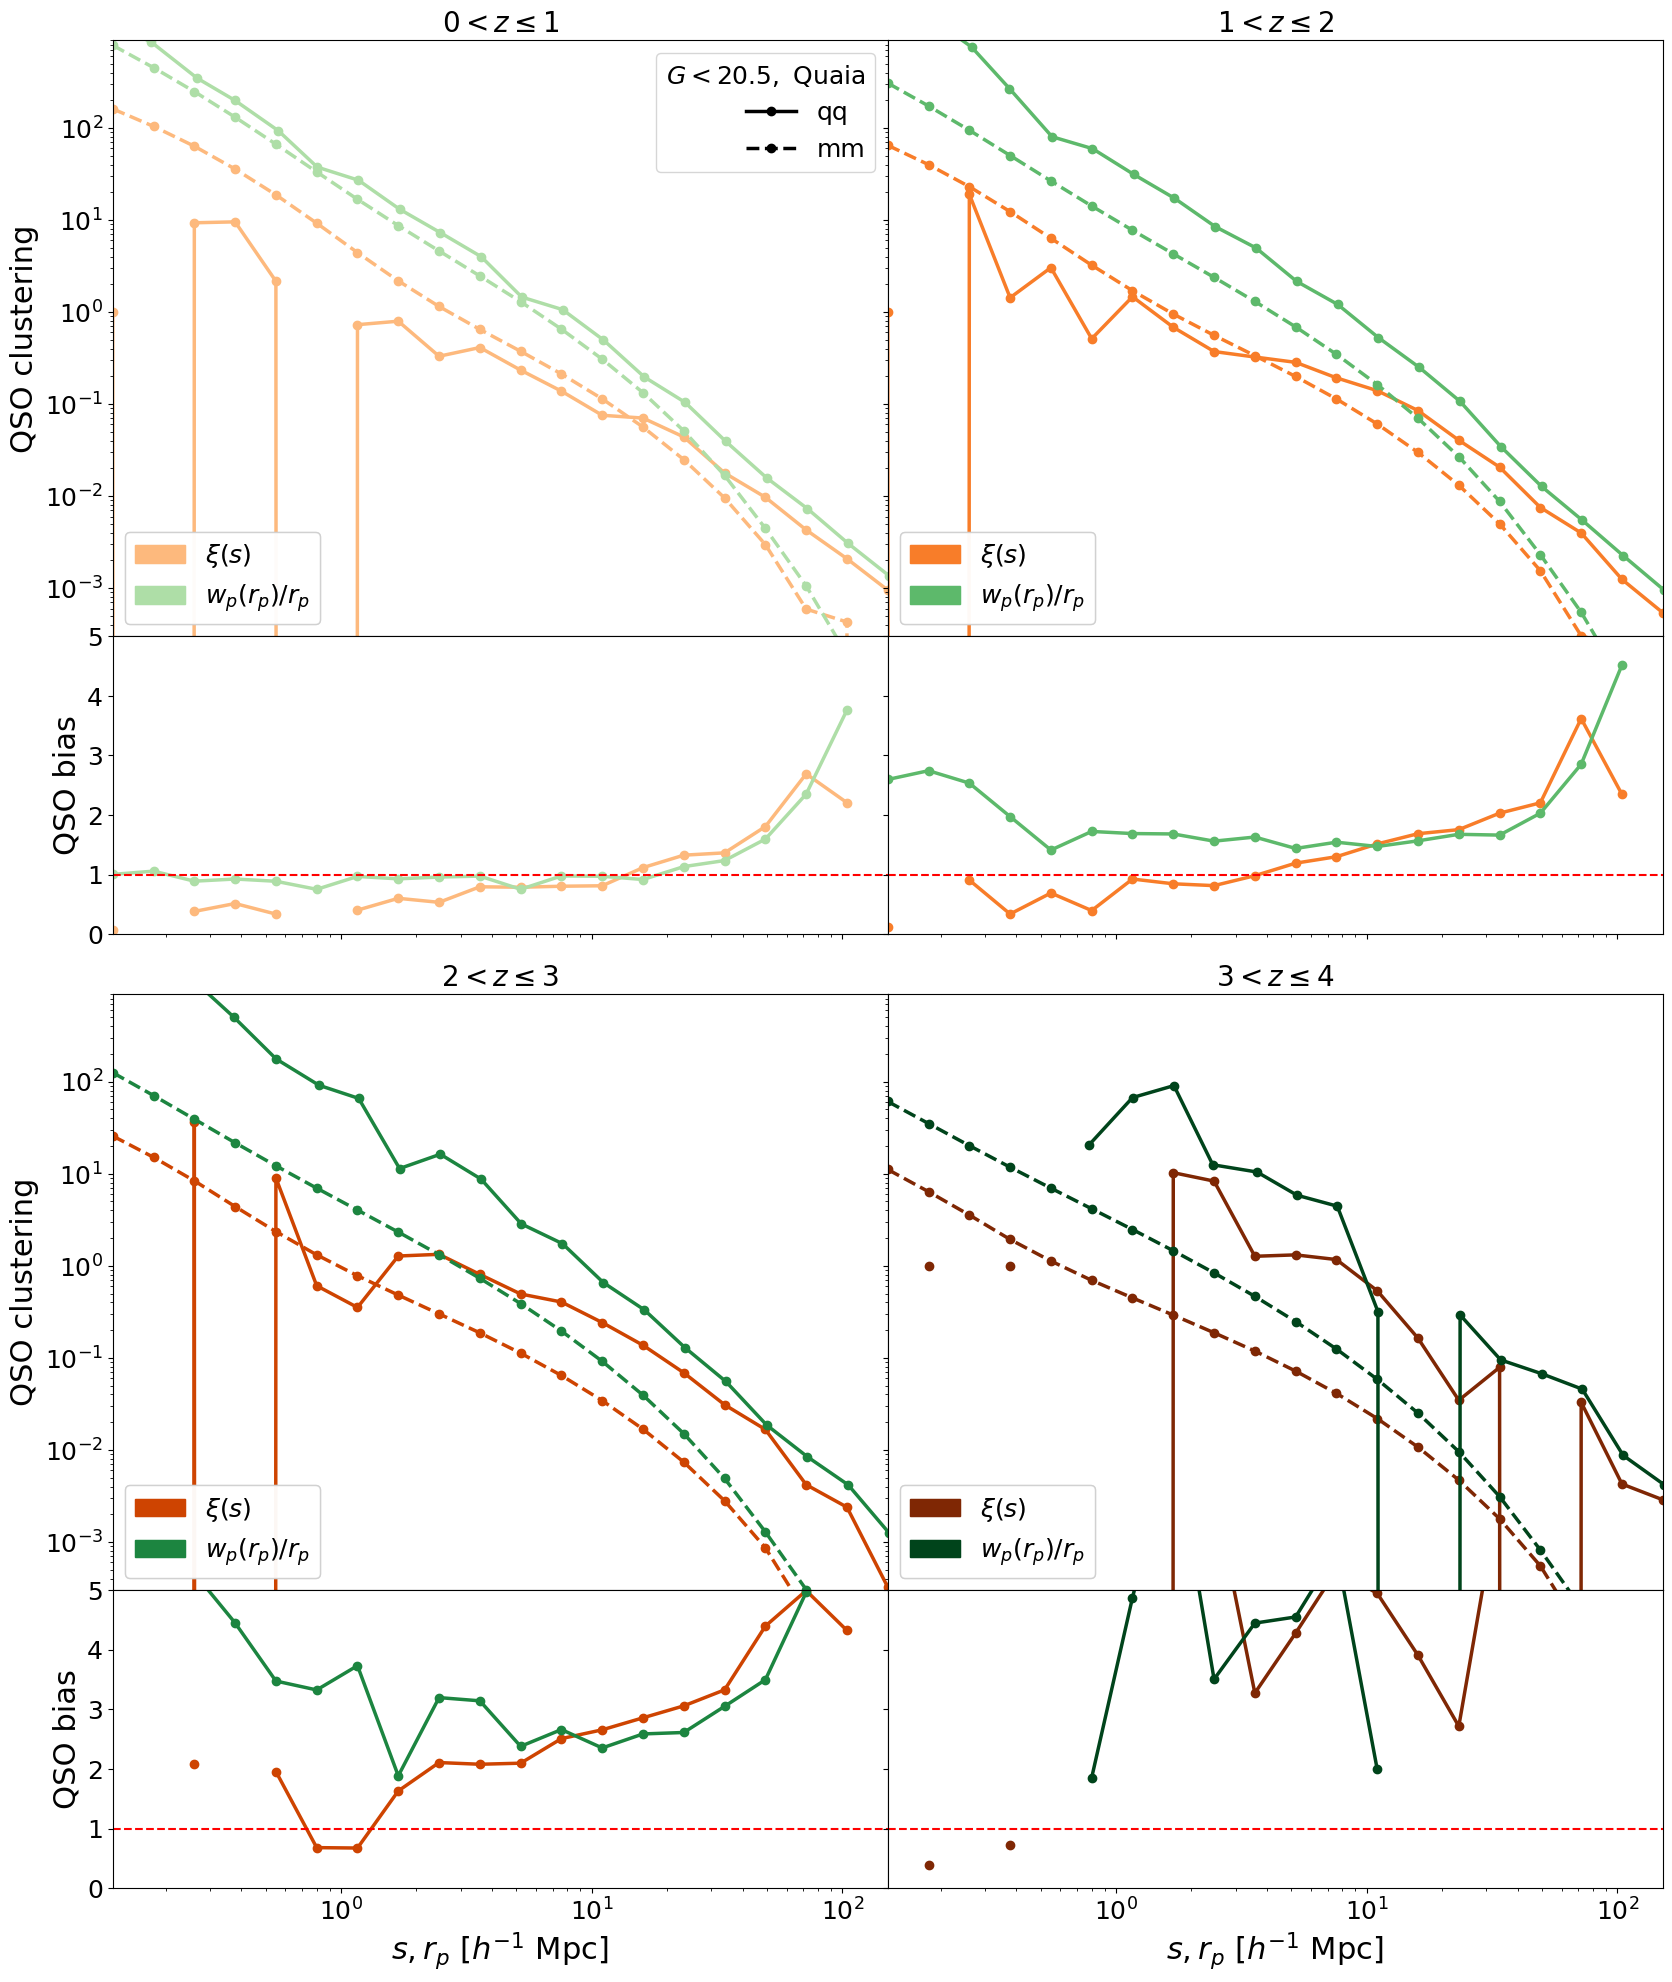

In [47]:
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.plot(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], linestyle = '--')

        ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
        
        #wp
        ax1.plot(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j]/rpavg_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_mm[j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], linestyle = '--')

        ax2.plot(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), 
                 color = cmap_mm[j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_157745/3176316175.py:18: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/3176316175.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1),
/tmp/ipykernel_157745/3176316175.py:28: SyntaxWarning: invalid es

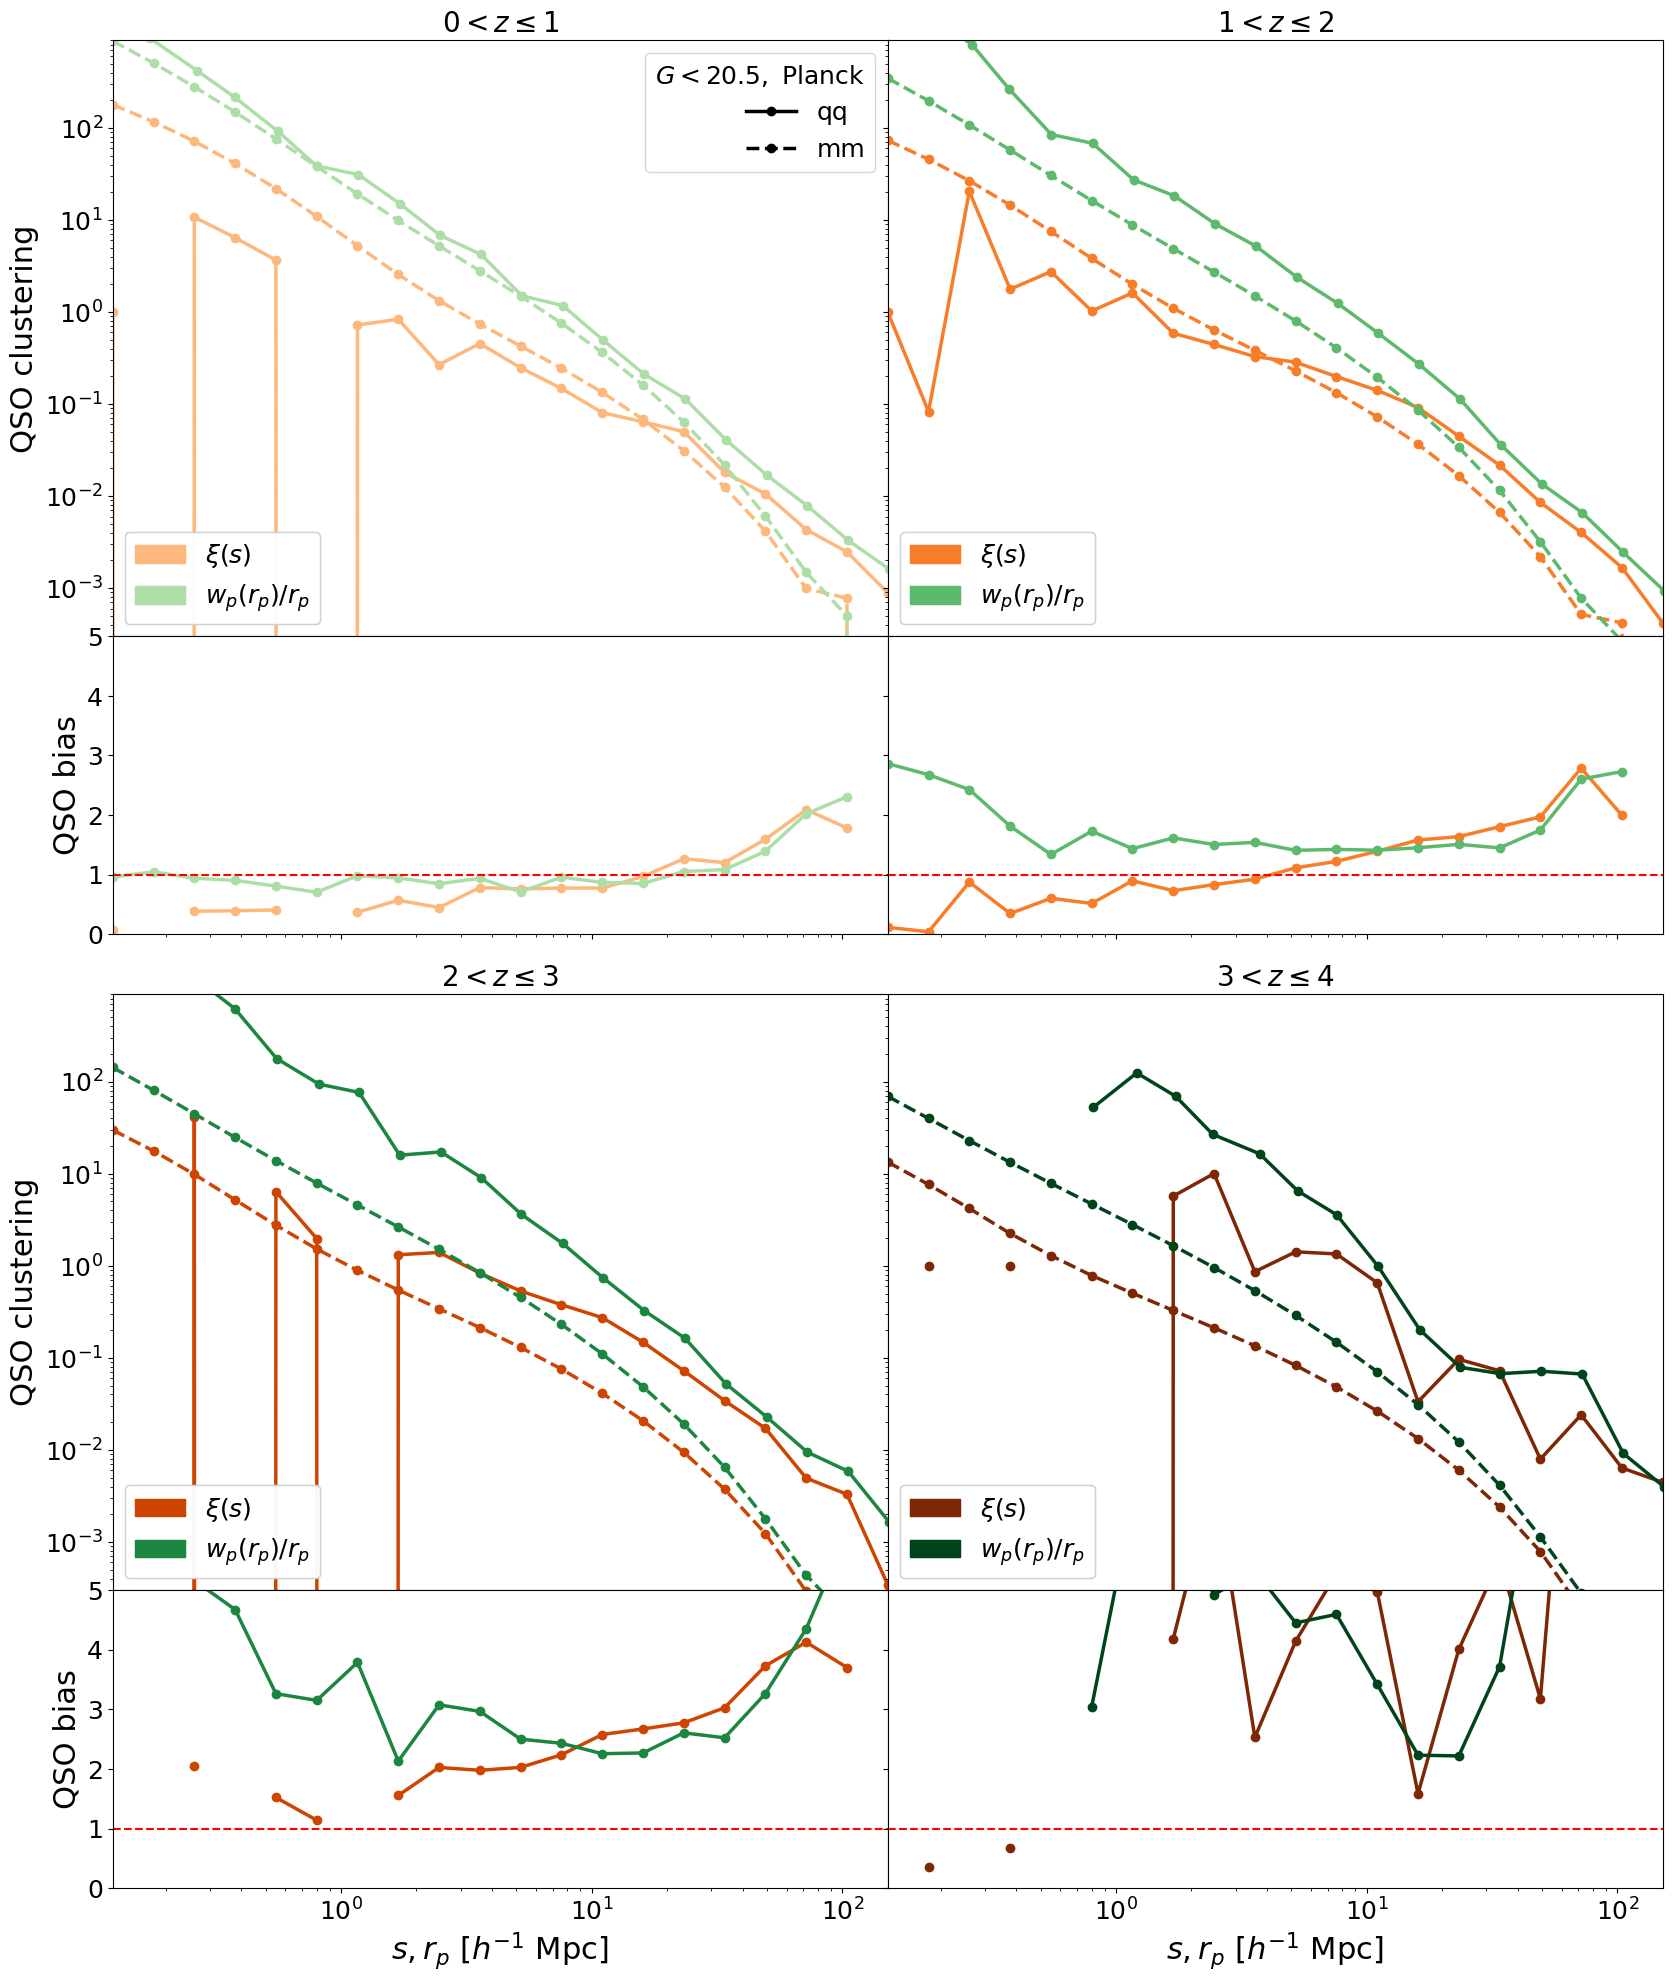

/tmp/ipykernel_157745/3176316175.py:18: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_157745/3176316175.py:18: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_157745/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_157745/3176316175.py:18: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins)

In [ ]:
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.plot(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], linestyle = '--')

        ax2.plot(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
        
        #wp
        ax1.plot(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j]/rpavg_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_mm[j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], linestyle = '--')

        ax2.plot(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), 
                 color = cmap_mm[j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    plt.show()

## Plot b evolution at a fixed scale
### $\xi(z)$

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rbins)-10))

for i in range(len(labels)):
    
    cf_zbin_percentile_k = np.array([cf_zbin_percentile[labels[i]][j][k] for j in z_array])
    cf_matter_zbin_percentile_k = [cf_matter_zbin_percentile[labels[i]][j][k] for j in z_array]

    # for j in z_array:
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_matter_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')

    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(cf_zbin_percentile_k/cf_matter_zbin_percentile_k), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

plt.show()

### $w_p(s)$

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rpbins)-10))

for i in range(len(labels)):
    
    wp_zbin_percentile_k = np.array([wp_zbin_percentile[labels[i]][j][k] for j in z_array])
    wp_matter_zbin_percentile_k = [wp_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_matter_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')

    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(wp_zbin_percentile_k/wp_matter_zbin_percentile_k), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_p({:.2f} h^{{-1}}$ Mpc) $[h^{{-1}}$ Mpc]'.format(quaia.recenter(rpbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rpbins)[k]))

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    # cf
    cf_zbin_percentile_k = np.array([cf_zbin_percentile[labels[i]][j][k] for j in z_array])
    cf_matter_zbin_percentile_k = [cf_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(cf_zbin_percentile_k/cf_matter_zbin_percentile_k), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
    # wp
    wp_zbin_percentile_k = np.array([wp_zbin_percentile[labels[i]][j][k] for j in z_array])
    wp_matter_zbin_percentile_k = [wp_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_zbin_percentile_k/quaia.recenter(rpbins)[k], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(wp_zbin_percentile_k/wp_matter_zbin_percentile_k), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)/r_p$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
ax1.set_title('$s,r_p = {:.2f}[h^{{-1}}$ Mpc]'.format(quaia.recenter(rbins)[k]))

patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi, w_p/r_p$')
# ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b$')

plt.show()

# Try the integration method
## Compute $\xi_{20}=3 / 20^3 \int_0^{20} \xi(s) s^2 d s$

In [ ]:
labels_cf = ['qq', 'mm']
cf_20={label: [] for label in labels}
cf_matter_20={label: [] for label in labels}
for i in range(len(Omega_m_array)):

    for j in z_array:

        # quasars
        bounds = quaia.recenter(rbins)<20
        integrand = np.copy(cf_zbin_percentile[labels[i]][j])*quaia.recenter(rbins)**2
        integrand[np.isnan(integrand)]=0
        cf_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rbins)[bounds]))
        
        # matter
        integrand = np.copy(cf_matter_zbin_percentile[labels[i]][j])*quaia.recenter(rbins)**2
        integrand[np.isnan(integrand)]=0
        cf_matter_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rbins)[bounds]))

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(cf_20[labels[i]])/cf_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Compute $w_{p,20}=2 / 20^2 \int_0^{20} w_p(r_p) r_p d r_p$

In [ ]:
labels_cf = ['qq', 'mm']
wp_20={label: [] for label in labels}
wp_matter_20={label: [] for label in labels}
for i in range(len(Omega_m_array)):

    for j in z_array:

        # quasars
        bounds = np.array(rpavg_zbin_percentile[labels[i]][j])<20
        integrand = np.copy(wp_zbin_percentile[labels[i]][j])*rpavg_zbin_percentile[labels[i]][j]
        integrand[np.isnan(integrand)]=0
        wp_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], np.array(rpavg_zbin_percentile[labels[i]][j])[bounds]))
        
        # matter
        integrand = np.copy(wp_matter_zbin_percentile[labels[i]][j])*quaia.recenter(rpbins)
        integrand[np.isnan(integrand)]=0
        wp_matter_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rpbins)[bounds]))

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(wp_20[labels[i]])/wp_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_{p,20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    # cf
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(cf_20[labels[i]])/cf_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
    # wp
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(wp_20[labels[i]])/wp_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}, w_{p,20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Calculate $b_{20,\mathrm{qq}}(z)=\sqrt{\frac{\xi^s_{\mathrm{20,qq}}}{\xi^r_\mathrm{20,mm}}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(cf_20[labels[i]]), cf_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], 
    axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Calculate $b_{20,\mathrm{qq}}(z)=\sqrt{\frac{w^s_{p,20,{\mathrm{qq}}}}{w^r_{p,20\mathrm{mm}}}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(wp_20[labels[i]]), wp_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_{p,20}$')
# ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    # cf
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(cf_20[labels[i]]), cf_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
    # wp
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(wp_20[labels[i]]), wp_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}, w_{p,20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()